# AZFc architectural-constraint modeling

This notebook tests whether the observed human AZFc architectural repertoire is more
restricted than expected under a deliberately permissive, phylogenetically explicit
internal-NAHR mutation model.

### Primary analysis set

- 100 AZFc-QC chromosomes are retained for descriptive summaries.
- Architecture:2 and Architecture:10 are excluded from the primary mechanistic null
  because their defining inversions extend outside the modeled AZFc amplicon-block
  system.
- The primary internal-NAHR simulation therefore uses 98 chromosomes and 10 observed
  architectures.

### Null #1 mutation model

- Same-color blocks are homologous candidate NAHR substrates.
- Oppositely oriented homologous blocks can generate inversions.
- Directly oriented homologous blocks can generate deletions or reciprocal tandem
  duplications.
- Structurally silent products are excluded.
- A homologous substrate pair is chosen uniformly; for a direct pair, deletion versus
  duplication is chosen uniformly.
- Events evolve dynamically along the empirical Y phylogeny in continuous branch-length
  time.
- Null replicates are conditioned on the empirical amount of structural evolution:
  exactly 30 state-changing internal-NAHR events.

## 1. Imports, paths, and analysis settings

In [1]:
import json
import copy
from collections import Counter, deque
from pathlib import Path

import numpy as np
import pandas as pd
from Bio import Phylo

In [2]:
QC_PATH = "/Users/markloftus/Desktop/UCONN/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv"
STRUCTURE_PATH = "/Users/markloftus/Desktop/UCONN/LeeLab/HPRC/chromosomeY/Data/UniqueAZFc_Structures.tsv"
ARCHITECTURE_PATH = "/Users/markloftus/Desktop/UCONN/LeeLab/HPRC/chromosomeY/Data/AZFc_100Samples_blockCount_Architecture.03172026.csv"
TREE_PATH = (
    "/Users/markloftus/Desktop/UCONN/LeeLab/HPRC/chromosomeY/"
    "Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex"
)

EXTERNAL_INVERSION_ARCHITECTURES = {
    "Architecture:2",
    "Architecture:10",
}

RANDOM_SEED = 12345
N_TRACEBACK_REPLICATES = 5000
MAX_NAHR_SEARCH_DEPTH = 4

## 2. Load the QC set, exact structures, architecture labels, and Y phylogeny

In [3]:
# QC-passing AZFc regions
errDF = pd.read_csv(QC_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

structures1 = pd.read_csv(STRUCTURE_PATH, sep="\t", header=None)
structures1["samplename"] = [x.split("_chrY")[0] for x in structures1[1]]
structures1 = structures1.set_index("samplename")
structureOrderDict = dict(zip(structures1.index, structures1[2]))

# Manually defined large-scale architecture labels
structureDF = pd.read_csv(ARCHITECTURE_PATH)
index_col = "Unnamed: 0" if "Unnamed: 0" in structureDF.columns else structureDF.columns[0]
structureDF = structureDF.set_index(index_col)
architecturalGroupDict = dict(zip(structureDF.index.astype(str), structureDF["Architecture"]))

# Full Y phylogeny
trees = list(Phylo.parse(TREE_PATH, "nexus"))
if not trees:
    raise ValueError("No trees were found in the NEXUS file.")
tree = trees[0]

print("QC samples:", errDF["sample"].astype(str).nunique())
print("Samples with exact structures:", len(structureOrderDict))
print("Samples with architecture labels:", len(architecturalGroupDict))
print("Tree tips:", len(tree.get_terminals()))

QC samples: 100
Samples with exact structures: 100
Samples with architecture labels: 100
Tree tips: 142


## 3. Restrict all inputs to the same QC-passing samples

In [5]:
good_samples = set(errDF["sample"].astype(str))
structure_samples = set(structureOrderDict)
architecture_samples = set(architecturalGroupDict)
tree_samples = {tip.name for tip in tree.get_terminals()}

azfc_samples = (
    good_samples
    & structure_samples
    & architecture_samples
    & tree_samples
)

print("QC samples:", len(good_samples))
print("QC + exact structure:", len(good_samples & structure_samples))
print("QC + architecture label:", len(good_samples & architecture_samples))
print("QC + tree:", len(good_samples & tree_samples))
print("Usable AZFc samples:", len(azfc_samples))

# Preserve the original full tree.
tree_azfc = copy.deepcopy(tree)
for tip in list(tree_azfc.get_terminals()):
    if tip.name not in azfc_samples:
        tree_azfc.prune(tip)

assert {tip.name for tip in tree_azfc.get_terminals()} == azfc_samples
print("Pruned AZFc tree tips:", len(tree_azfc.get_terminals()))

QC samples: 100
QC + exact structure: 100
QC + architecture label: 100
QC + tree: 100
Usable AZFc samples: 100
Pruned AZFc tree tips: 100


## 4. Parse each architecture into an immutable block-order/orientation state

In [6]:
def parse_structure(structure_string):
    """Parse '-1_#1307b3_1_#ffff00_...' into family/orientation records."""

    tokens = str(structure_string).split("_")

    if len(tokens) % 2 != 0:
        raise ValueError(
            f"Structure has an odd number of tokens: {structure_string}"
        )

    blocks = []

    for i in range(0, len(tokens), 2):
        orientation = int(tokens[i])
        family = tokens[i + 1]

        if orientation not in (-1, 1):
            raise ValueError(f"Unexpected orientation: {orientation}")

        blocks.append({
            "family": family,
            "orientation": orientation,
        })

    return blocks


def structure_to_tuple(structure_string):
    """Convert a structure string to an immutable structural state."""

    return tuple(
        (block["family"], block["orientation"])
        for block in parse_structure(structure_string)
    )


def pretty_structure(structure):
    """Human-readable family + orientation representation."""

    return " ".join(
        f"{family}{'+' if orientation == 1 else '-'}"
        for family, orientation in structure
    )


structureTupleDict = {
    sample: structure_to_tuple(structure)
    for sample, structure in structureOrderDict.items()
    if sample in azfc_samples
}

assert set(structureTupleDict) == azfc_samples
print("Parsed structures:", len(structureTupleDict))

Parsed structures: 100


## 5. Build the observed-state table and verify the architecture definitions

In [7]:
model_df = pd.DataFrame({"sample": sorted(azfc_samples)})
model_df["architecture"] = model_df["sample"].map(architecturalGroupDict)
model_df["structure"] = model_df["sample"].map(structureTupleDict)

if model_df[["architecture", "structure"]].isna().any().any():
    raise ValueError("Missing architecture or exact structure for one or more samples.")

architecture_summary = (
    model_df
    .groupby("architecture")
    .agg(
        n_samples=("sample", "size"),
        n_exact_structures=("structure", "nunique"),
    )
    .sort_index()
)

display(architecture_summary)

K_obs = model_df["architecture"].nunique()
K_exact_obs = model_df["structure"].nunique()

print("Observed architecture labels:", K_obs)
print("Observed exact block structures:", K_exact_obs)

assert (architecture_summary["n_exact_structures"] == 1).all(), (
    "At least one architecture label maps to more than one exact block state."
)
assert K_obs == K_exact_obs, (
    "Architecture labels and exact block states are not one-to-one."
)

print("PASS: each architecture label corresponds to one exact block state.")

architecture_to_structure = (
    model_df
    .drop_duplicates("architecture")
    .set_index("architecture")["structure"]
    .to_dict()
)

structure_to_architecture = {
    structure: architecture
    for architecture, structure in architecture_to_structure.items()
}

,n_samples,n_exact_structures
architecture,,
Architecture:1,1,1
Architecture:10,1,1
Architecture:11,4,1
Architecture:12,1,1
Architecture:2,1,1
Architecture:3,63,1
Architecture:4,7,1
Architecture:5,5,1
Architecture:6,1,1


Observed architecture labels: 12
Observed exact block structures: 12
PASS: each architecture label corresponds to one exact block state.


In [8]:
architecture_counts = model_df["architecture"].value_counts().sort_index()
display(architecture_counts.rename("n_samples").to_frame())

freq = architecture_counts / architecture_counts.sum()
H_obs = float(-(freq * np.log(freq)).sum())
H_max_given_K = float(np.log(K_obs))
H_obs_normalized = H_obs / H_max_given_K if H_max_given_K > 0 else np.nan

print(f"Observed K: {K_obs}")
print(f"Observed Shannon entropy: {H_obs:.6f}")
print(f"Maximum entropy for K={K_obs}: {H_max_given_K:.6f}")
print(f"Normalized observed entropy: {H_obs_normalized:.6f}")

,n_samples
architecture,
Architecture:1,1
Architecture:10,1
Architecture:11,4
Architecture:12,1
Architecture:2,1
Architecture:3,63
Architecture:4,7
Architecture:5,5
Architecture:6,1


Observed K: 12
Observed Shannon entropy: 1.353390
Maximum entropy for K=12: 2.484907
Normalized observed entropy: 0.544644


## 6. Permissive AZFc-internal NAHR event model

For the first null model, same-color blocks are treated as homologous substrates.

- **Inverted pair** → inversion product.
- **Direct pair** → deletion and reciprocal tandem-duplication products.

In [9]:
def find_homologous_pairs(structure):
    """Enumerate every same-family block pair in one AZFc state."""

    pairs = []

    for i in range(len(structure)):
        family_i, orientation_i = structure[i]

        for j in range(i + 1, len(structure)):
            family_j, orientation_j = structure[j]

            if family_i != family_j:
                continue

            relationship = (
                "direct"
                if orientation_i == orientation_j
                else "inverted"
            )

            pairs.append({
                "left_index": i,
                "right_index": j,
                "family": family_i,
                "left_orientation": orientation_i,
                "right_orientation": orientation_j,
                "relationship": relationship,
            })

    return pairs


def find_possible_events(structure):
    """Enumerate candidate NAHR products from one block-level state."""

    events = []

    for pair in find_homologous_pairs(structure):

        if pair["relationship"] == "inverted":
            events.append({
                **pair,
                "event_type": "inversion",
            })

        else:
            events.append({
                **pair,
                "event_type": "deletion",
            })
            events.append({
                **pair,
                "event_type": "duplication",
            })

    return events

In [10]:
def apply_inversion(structure, i, j):
    """Invert inclusive interval i..j: reverse block order and flip orientation."""

    if i >= j:
        raise ValueError("i must be less than j")

    family_i, orientation_i = structure[i]
    family_j, orientation_j = structure[j]

    if family_i != family_j:
        raise ValueError("Inversion endpoints must be homologous families")
    if orientation_i == orientation_j:
        raise ValueError("Inversion requires oppositely oriented repeats")

    inverted_segment = tuple(
        (family, -orientation)
        for family, orientation in reversed(structure[i:j + 1])
    )

    return structure[:i] + inverted_segment + structure[j + 1:]


def apply_deletion(structure, i, j):
    """Delete interval i+1..j between directly oriented homologous repeats."""

    if i >= j:
        raise ValueError("i must be less than j")

    family_i, orientation_i = structure[i]
    family_j, orientation_j = structure[j]

    if family_i != family_j:
        raise ValueError("Deletion endpoints must be homologous families")
    if orientation_i != orientation_j:
        raise ValueError("Deletion requires directly oriented repeats")

    return structure[:i + 1] + structure[j + 1:]


def apply_duplication(structure, i, j):
    """Generate the reciprocal tandem-duplication product of direct-repeat NAHR."""

    if i >= j:
        raise ValueError("i must be less than j")

    family_i, orientation_i = structure[i]
    family_j, orientation_j = structure[j]

    if family_i != family_j:
        raise ValueError("Duplication endpoints must be homologous families")
    if orientation_i != orientation_j:
        raise ValueError("Duplication requires directly oriented repeats")

    duplicated_segment = structure[i + 1:j + 1]

    return (
        structure[:j + 1]
        + duplicated_segment
        + structure[j + 1:]
    )


def apply_event(structure, event):
    """Apply one event returned by find_possible_events()."""

    i = event["left_index"]
    j = event["right_index"]
    event_type = event["event_type"]

    if event_type == "inversion":
        return apply_inversion(structure, i, j)
    if event_type == "deletion":
        return apply_deletion(structure, i, j)
    if event_type == "duplication":
        return apply_duplication(structure, i, j)

    raise ValueError(f"Unknown event type: {event_type}")


def family_content(structure):
    return Counter(family for family, orientation in structure)


def event_changes_structure(structure, event):
    """Whether the event changes the block-level architecture."""

    return apply_event(structure, event) != structure


def find_state_changing_events(structure):
    """Candidate events that create a new block-level architecture."""

    return [
        event
        for event in find_possible_events(structure)
        if event_changes_structure(structure, event)
    ]

## 7. Validate the rearrangement operators on every observed architecture

In [11]:
def validate_event_operators(structure):
    """Structural sanity checks for all candidate events from one state."""

    for event in find_possible_events(structure):
        result = apply_event(structure, event)
        i = event["left_index"]
        j = event["right_index"]

        assert all(
            orientation in (-1, 1)
            for family, orientation in result
        )

        if event["event_type"] == "inversion":
            assert len(result) == len(structure)
            assert family_content(result) == family_content(structure)

        elif event["event_type"] == "deletion":
            expected_loss = j - i
            assert len(structure) - len(result) == expected_loss

        elif event["event_type"] == "duplication":
            expected_gain = j - i
            assert len(result) - len(structure) == expected_gain

    return True


validation_results = {
    architecture: validate_event_operators(structure)
    for architecture, structure in architecture_to_structure.items()
}

assert all(validation_results.values())
print(f"PASS: operators validated on all {len(validation_results)} observed architectures.")

PASS: operators validated on all 12 observed architectures.


## 8. Enumerate the one-step accessible state space

This is a diagnostic, not yet the statistical null test. It asks how many distinct
block-level products the permissive event model can generate in one step and how often
those products coincide with one of the observed natural architectures.

In [12]:
def enumerate_one_step_outcomes(source_architecture, structure):
    rows = []

    for event in find_state_changing_events(structure):
        new_structure = apply_event(structure, event)

        rows.append({
            "source_architecture": source_architecture,
            "event_type": event["event_type"],
            "family": event["family"],
            "left_index": event["left_index"],
            "right_index": event["right_index"],
            "destination_architecture": structure_to_architecture.get(new_structure),
            "new_structure": new_structure,
        })

    return pd.DataFrame(rows)


one_step_frames = [
    enumerate_one_step_outcomes(architecture, structure)
    for architecture, structure in architecture_to_structure.items()
]

one_step_transitions = pd.concat(one_step_frames, ignore_index=True)

observed_one_step = (
    one_step_transitions
    .dropna(subset=["destination_architecture"])
    .copy()
)

transition_pairs = (
    observed_one_step[
        ["source_architecture", "destination_architecture"]
    ]
    .drop_duplicates()
    .sort_values(["source_architecture", "destination_architecture"])
)

print("Total state-changing NAHR events considered:", len(one_step_transitions))
print("Unique one-step structural products:", one_step_transitions["new_structure"].nunique())
print(
    "Events producing one of the observed architectures:",
    observed_one_step.shape[0]
)
print(
    "Unique observed architecture-to-architecture transitions:",
    transition_pairs.shape[0]
)

display(transition_pairs)

Total state-changing NAHR events considered: 237
Unique one-step structural products: 83
Events producing one of the observed architectures: 46
Unique observed architecture-to-architecture transitions: 17


,source_architecture,destination_architecture
63,Architecture:1,Architecture:5
38,Architecture:11,Architecture:12
134,Architecture:12,Architecture:11
6,Architecture:3,Architecture:4
3,Architecture:3,Architecture:5
8,Architecture:3,Architecture:7
46,Architecture:5,Architecture:1
52,Architecture:5,Architecture:11
47,Architecture:5,Architecture:3
108,Architecture:6,Architecture:3


In [13]:
transition_check = observed_one_step[
    [
        "source_architecture",
        "destination_architecture",
        "event_type",
    ]
].copy()


def has_reverse_transition(row, transition_df):
    return (
        (
            (transition_df["source_architecture"] == row["destination_architecture"])
            &
            (transition_df["destination_architecture"] == row["source_architecture"])
        )
        .any()
    )


transition_check["has_reverse"] = transition_check.apply(
    lambda row: has_reverse_transition(row, observed_one_step),
    axis=1,
)

reciprocity_summary = (
    transition_check
    .groupby("event_type")
    .agg(
        n_transitions=("event_type", "size"),
        n_reciprocal=("has_reverse", "sum"),
    )
)

reciprocity_summary["fraction_reciprocal"] = (
    reciprocity_summary["n_reciprocal"]
    / reciprocity_summary["n_transitions"]
)

display(reciprocity_summary)

,n_transitions,n_reciprocal,fraction_reciprocal
event_type,,,
deletion,32,8,0.25
duplication,2,2,1.00
inversion,12,12,1.00


## 9. Define the primary AZFc-internal NAHR analysis set

Architectures 2 and 10 contain an inversion whose breakpoint extends into sequence
outside the modeled AZFc color-block system. They therefore cannot be generated by the
current AZFc-internal NAHR operators.

They remain in the 100-sample descriptive analysis above. The primary mechanistic
constraint analysis below is restricted to chromosomes whose architecture is contained
within the modeled AZFc amplicon system.

In [14]:
internal_architectures = (
    set(architecture_to_structure)
    - EXTERNAL_INVERSION_ARCHITECTURES
)

internal_samples = {
    sample
    for sample in azfc_samples
    if architecturalGroupDict[sample] in internal_architectures
}

internal_model_df = (
    model_df[model_df["sample"].isin(internal_samples)]
    .copy()
)

internal_architecture_to_structure = {
    architecture: architecture_to_structure[architecture]
    for architecture in sorted(internal_architectures)
}

print("All QC AZFc samples:", len(azfc_samples))
print("Internal-NAHR samples:", len(internal_samples))
print("All observed architectures:", K_obs)
print("Internal-NAHR architectures:", len(internal_architectures))
print(
    "Excluded external-inversion samples:",
    sorted(set(azfc_samples) - internal_samples)
)

display(
    internal_model_df["architecture"]
    .value_counts()
    .sort_index()
    .rename("n_samples")
    .to_frame()
)

tree_internal = copy.deepcopy(tree_azfc)
for tip in list(tree_internal.get_terminals()):
    if tip.name not in internal_samples:
        tree_internal.prune(tip)

assert {tip.name for tip in tree_internal.get_terminals()} == internal_samples
print("Internal-NAHR tree tips:", len(tree_internal.get_terminals()))

All QC AZFc samples: 100
Internal-NAHR samples: 98
All observed architectures: 12
Internal-NAHR architectures: 10
Excluded external-inversion samples: ['HG02666', 'NA20905']


,n_samples
architecture,
Architecture:1,1
Architecture:11,4
Architecture:12,1
Architecture:3,63
Architecture:4,7
Architecture:5,5
Architecture:6,1
Architecture:7,14
Architecture:8,1


Internal-NAHR tree tips: 98


In [15]:
internal_counts = internal_model_df["architecture"].value_counts().sort_index()
internal_freq = internal_counts / internal_counts.sum()

K_internal = internal_model_df["architecture"].nunique()
H_internal = float(-(internal_freq * np.log(internal_freq)).sum())
H_internal_max = float(np.log(K_internal))
H_internal_normalized = (
    H_internal / H_internal_max if H_internal_max > 0 else np.nan
)

print(f"Internal observed K: {K_internal}")
print(f"Internal Shannon entropy: {H_internal:.6f}")
print(f"Internal normalized entropy: {H_internal_normalized:.6f}")

Internal observed K: 10
Internal Shannon entropy: 1.266824
Internal normalized entropy: 0.550175


## 10. Generic state-space search for NAHR-event distances

In [16]:
def explore_state_space(start_structure, max_depth=MAX_NAHR_SEARCH_DEPTH):
    """Return minimum forward NAHR-event distance to every state reached."""

    distances = {start_structure: 0}
    queue = deque([start_structure])

    while queue:
        structure = queue.popleft()
        depth = distances[structure]

        if depth >= max_depth:
            continue

        for event in find_state_changing_events(structure):
            new_structure = apply_event(structure, event)

            if new_structure in distances:
                continue

            distances[new_structure] = depth + 1
            queue.append(new_structure)

    return distances

## 11. Fitch parsimony on the observed Y phylogeny

Fitch parsimony treats every architecture change as one unordered state change. This is
a descriptive first pass: it quantifies the minimum number of independent architecture
changes required by the phylogeny before we account for the fact that some architecture
transitions require multiple NAHR events.

In [17]:
def fitch_parsimony(tree, state_dict):
    """Fitch parsimony for unordered discrete architecture states."""

    state_sets = {}
    score = 0

    for clade in tree.find_clades(order="postorder"):

        if clade.is_terminal():
            state_sets[clade] = {state_dict[clade.name]}
            continue

        child_sets = [state_sets[child] for child in clade.clades]
        current_set = child_sets[0].copy()

        for next_set in child_sets[1:]:
            intersection = current_set & next_set

            if intersection:
                current_set = intersection
            else:
                current_set = current_set | next_set
                score += 1

        state_sets[clade] = current_set

    return score, state_sets


def fitch_traceback(tree, state_sets, root_state):
    """One deterministic most-parsimonious traceback for a specified root state."""

    if root_state not in state_sets[tree.root]:
        raise ValueError(f"{root_state} is not an allowed Fitch root state.")

    assigned_states = {tree.root: root_state}
    transitions = []

    for parent in tree.find_clades(order="preorder"):
        parent_state = assigned_states[parent]

        for child in parent.clades:
            allowed = state_sets[child]

            if parent_state in allowed:
                child_state = parent_state
            else:
                child_state = sorted(allowed)[0]

            assigned_states[child] = child_state

            if child_state != parent_state:
                transitions.append({
                    "parent_state": parent_state,
                    "child_state": child_state,
                    "child_name": child.name if child.name is not None else "internal",
                })

    return assigned_states, transitions

In [18]:
fitch_score_all, fitch_state_sets_all = fitch_parsimony(
    tree_azfc,
    architecturalGroupDict,
)

print("FULL DATASET")
print("Minimum architecture-state changes:", fitch_score_all)
print(
    "Possible root states:",
    sorted(fitch_state_sets_all[tree_azfc.root])
)

FULL DATASET
Minimum architecture-state changes: 25
Possible root states: ['Architecture:1', 'Architecture:2', 'Architecture:3']


In [19]:
fitch_score_internal, fitch_state_sets_internal = fitch_parsimony(
    tree_internal,
    architecturalGroupDict,
)

possible_roots_internal = sorted(
    fitch_state_sets_internal[tree_internal.root]
)

print("INTERNAL-NAHR DATASET")
print("Minimum architecture-state changes:", fitch_score_internal)
print("Possible root states:", possible_roots_internal)

INTERNAL-NAHR DATASET
Minimum architecture-state changes: 23
Possible root states: ['Architecture:1', 'Architecture:3']


## 12. Inspect one optimal transition history for every equally parsimonious root

In [20]:
traceback_results_internal = {}
deterministic_transition_rows = []

for root_state in possible_roots_internal:

    assigned, transitions = fitch_traceback(
        tree_internal,
        fitch_state_sets_internal,
        root_state,
    )

    assert len(transitions) == fitch_score_internal

    traceback_results_internal[root_state] = {
        "assigned": assigned,
        "transitions": transitions,
    }

    counts = Counter(
        (x["parent_state"], x["child_state"])
        for x in transitions
    )

    for (parent_state, child_state), count in counts.items():
        deterministic_transition_rows.append({
            "root_state": root_state,
            "parent_state": parent_state,
            "child_state": child_state,
            "count": count,
        })

deterministic_transition_counts = pd.DataFrame(
    deterministic_transition_rows
).sort_values(
    ["root_state", "count", "parent_state", "child_state"],
    ascending=[True, False, True, True],
)

display(deterministic_transition_counts)

,root_state,parent_state,child_state,count
4,Architecture:1,Architecture:3,Architecture:7,8
1,Architecture:1,Architecture:3,Architecture:4,4
2,Architecture:1,Architecture:3,Architecture:5,4
0,Architecture:1,Architecture:1,Architecture:3,1
8,Architecture:1,Architecture:11,Architecture:12,1
7,Architecture:1,Architecture:3,Architecture:11,1
3,Architecture:1,Architecture:3,Architecture:6,1
9,Architecture:1,Architecture:5,Architecture:7,1
6,Architecture:1,Architecture:7,Architecture:8,1
5,Architecture:1,Architecture:7,Architecture:9,1


## 13. Sensitivity to ambiguous ancestral-state choices

This randomly resolves Fitch ties while preserving the minimum parsimony score.
It is a **tie-resolution sensitivity analysis**, not a claim that the sampled histories
are a uniform posterior distribution over all possible ancestral reconstructions.

In [21]:
def fitch_traceback_random(tree, state_sets, root_state, rng):
    """Randomly resolve ambiguous states in one minimum-parsimony traceback."""

    if root_state not in state_sets[tree.root]:
        raise ValueError(f"{root_state} is not an allowed root state.")

    assigned_states = {tree.root: root_state}
    transitions = []

    for parent in tree.find_clades(order="preorder"):
        parent_state = assigned_states[parent]

        for child in parent.clades:
            allowed = state_sets[child]

            if parent_state in allowed:
                child_state = parent_state
            else:
                child_state = rng.choice(sorted(allowed))

            assigned_states[child] = child_state

            if child_state != parent_state:
                transitions.append((parent_state, child_state))

    return transitions

In [22]:
rng = np.random.default_rng(RANDOM_SEED)

random_transition_counters = {
    root_state: []
    for root_state in possible_roots_internal
}

all_random_transition_types = set()

for root_state in possible_roots_internal:

    for replicate in range(N_TRACEBACK_REPLICATES):

        transitions = fitch_traceback_random(
            tree_internal,
            fitch_state_sets_internal,
            root_state,
            rng,
        )

        assert len(transitions) == fitch_score_internal

        counts = Counter(transitions)
        random_transition_counters[root_state].append(counts)
        all_random_transition_types.update(counts)


summary_rows = []

for root_state in possible_roots_internal:
    counters = random_transition_counters[root_state]

    for parent_state, child_state in sorted(all_random_transition_types):

        values = np.array([
            counter.get((parent_state, child_state), 0)
            for counter in counters
        ])

        if values.max() == 0:
            continue

        summary_rows.append({
            "root_state": root_state,
            "transition": f"{parent_state} -> {child_state}",
            "min_count": int(values.min()),
            "median_count": float(np.median(values)),
            "max_count": int(values.max()),
            "fraction_reconstructions_present": float((values > 0).mean()),
        })


random_transition_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(
        [
            "fraction_reconstructions_present",
            "median_count",
            "root_state",
            "transition",
        ],
        ascending=[False, False, True, True],
    )
)

display(random_transition_summary)

,root_state,transition,min_count,median_count,max_count,fraction_reconstructions_present
6,Architecture:1,Architecture:3 -> Architecture:7,7,8.0,9,1.0000
23,Architecture:3,Architecture:3 -> Architecture:7,7,8.0,9,1.0000
3,Architecture:1,Architecture:3 -> Architecture:4,4,4.0,4,1.0000
4,Architecture:1,Architecture:3 -> Architecture:5,3,4.0,4,1.0000
20,Architecture:3,Architecture:3 -> Architecture:4,4,4.0,4,1.0000
21,Architecture:3,Architecture:3 -> Architecture:5,3,4.0,4,1.0000
0,Architecture:1,Architecture:1 -> Architecture:3,1,1.0,1,1.0000
1,Architecture:1,Architecture:11 -> Architecture:12,1,1.0,1,1.0000
2,Architecture:1,Architecture:3 -> Architecture:11,1,1.0,1,1.0000
5,Architecture:1,Architecture:3 -> Architecture:6,1,1.0,1,1.0000


In [23]:
robust_recurrent_transitions = (
    random_transition_summary[
        (random_transition_summary["fraction_reconstructions_present"] == 1.0)
        &
        (random_transition_summary["median_count"] > 1)
    ]
    .copy()
)

display(robust_recurrent_transitions)

,root_state,transition,min_count,median_count,max_count,fraction_reconstructions_present
6,Architecture:1,Architecture:3 -> Architecture:7,7,8.0,9,1.0
23,Architecture:3,Architecture:3 -> Architecture:7,7,8.0,9,1.0
3,Architecture:1,Architecture:3 -> Architecture:4,4,4.0,4,1.0
4,Architecture:1,Architecture:3 -> Architecture:5,3,4.0,4,1.0
20,Architecture:3,Architecture:3 -> Architecture:4,4,4.0,4,1.0
21,Architecture:3,Architecture:3 -> Architecture:5,3,4.0,4,1.0


## 14. Minimum forward NAHR-event distances for inferred transition types

Ordinary Fitch parsimony assigns every architecture change a cost of 1. The structural
model lets us ask whether an inferred architecture transition actually requires one,
two, three, or more sequential AZFc-internal NAHR events.

In [24]:
all_inferred_internal_transitions = sorted({
    (
        row["parent_state"],
        row["child_state"],
    )
    for result in traceback_results_internal.values()
    for row in result["transitions"]
})

print(
    "Unique transition types across deterministic internal reconstructions:",
    len(all_inferred_internal_transitions)
)

source_cache = {}
transition_distance_rows = []

for source, destination in all_inferred_internal_transitions:

    if source not in source_cache:
        source_cache[source] = explore_state_space(
            internal_architecture_to_structure[source],
            max_depth=MAX_NAHR_SEARCH_DEPTH,
        )

    distance = source_cache[source].get(
        internal_architecture_to_structure[destination]
    )

    transition_distance_rows.append({
        "source_architecture": source,
        "destination_architecture": destination,
        "minimum_nahr_events": distance,
    })


transition_distance_df = pd.DataFrame(
    transition_distance_rows
)

display(transition_distance_df)

unresolved_internal_transitions = transition_distance_df[
    transition_distance_df["minimum_nahr_events"].isna()
]

if unresolved_internal_transitions.empty:
    print(
        f"All inferred internal transitions were reached within "
        f"{MAX_NAHR_SEARCH_DEPTH} NAHR events."
    )
else:
    print(
        "Transitions unresolved within the current search depth "
        "(inspect before increasing depth):"
    )
    display(unresolved_internal_transitions)

Unique transition types across deterministic internal reconstructions: 11


,source_architecture,destination_architecture,minimum_nahr_events
0,Architecture:1,Architecture:3,2
1,Architecture:11,Architecture:12,1
2,Architecture:3,Architecture:1,2
3,Architecture:3,Architecture:11,2
4,Architecture:3,Architecture:4,1
5,Architecture:3,Architecture:5,1
6,Architecture:3,Architecture:6,2
7,Architecture:3,Architecture:7,1
8,Architecture:5,Architecture:7,2
9,Architecture:7,Architecture:8,1


All inferred internal transitions were reached within 4 NAHR events.


## 15. Empirical minimum number of underlying AZFc-internal NAHR events

Ordinary Fitch parsimony gives the minimum number of architecture changes, but some
architecture transitions require more than one NAHR event in the block-level model.
Here we convert each inferred transition into its minimum forward NAHR cost and assess
the total cost across deterministic and randomized equally parsimonious reconstructions.

The current data support a primary conditioning value of 30 state-changing NAHR
events, with 31 and 32 available later as sensitivity analyses.

In [25]:
nahr_cost_lookup = {
    (
        row["source_architecture"],
        row["destination_architecture"],
    ): int(row["minimum_nahr_events"])
    for _, row in transition_distance_df.iterrows()
    if pd.notna(row["minimum_nahr_events"])
}

empirical_nahr_rows = []

for root_state in possible_roots_internal:

    transitions = traceback_results_internal[root_state]["transitions"]
    total_cost = 0

    for transition in transitions:
        edge = (
            transition["parent_state"],
            transition["child_state"],
        )

        if edge not in nahr_cost_lookup:
            raise ValueError(
                f"No NAHR cost available for transition: {edge}"
            )

        total_cost += nahr_cost_lookup[edge]

    empirical_nahr_rows.append({
        "root_state": root_state,
        "architecture_changes": len(transitions),
        "minimum_nahr_events": total_cost,
    })

empirical_nahr_summary = pd.DataFrame(empirical_nahr_rows)
display(empirical_nahr_summary)

,root_state,architecture_changes,minimum_nahr_events
0,Architecture:1,23,30
1,Architecture:3,23,30


In [26]:
random_transition_types = set()

for root_state, counters in random_transition_counters.items():
    for counter in counters:
        random_transition_types.update(counter.keys())

random_nahr_cost_lookup = dict(nahr_cost_lookup)

missing_costs = [
    edge
    for edge in sorted(random_transition_types)
    if edge not in random_nahr_cost_lookup
]

print(
    "Unique transition types across randomized reconstructions:",
    len(random_transition_types),
)
print(
    "Transition types requiring additional NAHR-distance calculation:",
    len(missing_costs),
)

random_source_cache = {}

for source, destination in missing_costs:

    if source not in random_source_cache:
        random_source_cache[source] = explore_state_space(
            internal_architecture_to_structure[source],
            max_depth=MAX_NAHR_SEARCH_DEPTH,
        )

    distance = random_source_cache[source].get(
        internal_architecture_to_structure[destination]
    )

    if distance is None:
        raise ValueError(
            f"Randomized reconstruction contains transition "
            f"{source} -> {destination}, but it was not reachable "
            f"within {MAX_NAHR_SEARCH_DEPTH} NAHR events."
        )

    random_nahr_cost_lookup[(source, destination)] = int(distance)

random_nahr_rows = []

for root_state, counters in random_transition_counters.items():

    for replicate, counter in enumerate(counters):

        total_nahr_cost = sum(
            count * random_nahr_cost_lookup[edge]
            for edge, count in counter.items()
        )

        random_nahr_rows.append({
            "root_state": root_state,
            "replicate": replicate,
            "architecture_changes": fitch_score_internal,
            "minimum_nahr_events": total_nahr_cost,
        })

random_nahr_totals = pd.DataFrame(random_nahr_rows)

random_nahr_summary = (
    random_nahr_totals
    .groupby("root_state")["minimum_nahr_events"]
    .agg(
        n="size",
        minimum="min",
        q025=lambda x: x.quantile(0.025),
        median="median",
        mean="mean",
        q975=lambda x: x.quantile(0.975),
        maximum="max",
    )
)

display(random_nahr_summary)

display(
    random_nahr_totals.groupby(
        ["root_state", "minimum_nahr_events"]
    )
    .size()
    .rename("n_reconstructions")
    .reset_index()
)

Unique transition types across randomized reconstructions: 18
Transition types requiring additional NAHR-distance calculation: 7


,n,minimum,q025,median,mean,q975,maximum
root_state,,,,,,,
Architecture:1,5000,30,30.0,30.0,30.4840,32.0,32
Architecture:3,5000,30,30.0,30.0,30.4938,32.0,32


,root_state,minimum_nahr_events,n_reconstructions
0,Architecture:1,30,3399
1,Architecture:1,31,782
2,Architecture:1,32,819
3,Architecture:3,30,3377
4,Architecture:3,31,777
5,Architecture:3,32,846


In [27]:
N_EMPIRICAL_NAHR_EVENTS = int(
    empirical_nahr_summary["minimum_nahr_events"].min()
)

print(
    "Primary number of state-changing NAHR events:",
    N_EMPIRICAL_NAHR_EVENTS,
)

Primary number of state-changing NAHR events: 30


## 16. Tree geometry for the dynamic branch process

Branch lengths provide the evolutionary-time scale for the continuous-time null.A branch receives events only
while its currently inherited architecture has at least one state-changing NAHR
product.

The initial rate scale below is simply the observed event count divided by total tree
length. A common rate is then calibrated across both possible root states for efficient
exact-count conditioning.

In [28]:
branch_rows = []
branch_clades = []

for branch_id, clade in enumerate(
    c
    for c in tree_internal.find_clades(order="preorder")
    if c is not tree_internal.root
):
    branch_rows.append({
        "branch_id": branch_id,
        "child_name": (
            clade.name
            if clade.name is not None
            else f"internal_{branch_id}"
        ),
        "is_terminal": clade.is_terminal(),
        "branch_length": clade.branch_length,
    })
    branch_clades.append(clade)

branch_df = pd.DataFrame(branch_rows)

if branch_df["branch_length"].isna().any():
    raise ValueError("Tree contains missing branch lengths.")

if (branch_df["branch_length"] <= 0).any():
    raise ValueError("Tree contains zero or negative branch lengths.")

TREE_TOTAL_LENGTH = float(
    branch_df["branch_length"].sum()
)

INITIAL_NAHR_RATE = (
    N_EMPIRICAL_NAHR_EVENTS
    / TREE_TOTAL_LENGTH
)

print("Number of branches:", len(branch_df))
print("Minimum branch length:", branch_df["branch_length"].min())
print("Maximum branch length:", branch_df["branch_length"].max())
print("Total tree length:", TREE_TOTAL_LENGTH)
print("Initial NAHR rate per branch-length unit:", INITIAL_NAHR_RATE)

display(
    branch_df.sort_values(
        "branch_length",
        ascending=False,
    ).head(10)
)

Number of branches: 194
Minimum branch length: 2.7e-05
Maximum branch length: 0.184292
Total tree length: 2.322486
Initial NAHR rate per branch-length unit: 12.91719304228314


,branch_id,child_name,is_terminal,branch_length
0,0,HG01890,True,0.184292
2,2,HG03225,True,0.106121
1,1,internal_1,False,0.078171
72,72,HG02040,True,0.057294
70,70,NA18974,True,0.055585
6,6,HG005,True,0.053413
85,85,HG01167,True,0.050340
98,98,HG01192,True,0.050174
67,67,internal_67,False,0.045201
11,11,internal_11,False,0.043794


## 17. Null #1 event-selection rule

The **substrate pair** is the unit of opportunity in the permissive null.

For any current architecture:

1. enumerate homologous same-family pairs that can generate at least one
   state-changing product;
2. choose one such pair uniformly;
3. for an inverted pair, the product is an inversion;
4. for a direct pair, choose deletion versus tandem duplication uniformly among
   state-changing products.

In [29]:
def enumerate_null1_pair_products(structure):
    """
    Return the state-changing product menu grouped by homologous pair.

    Each list element corresponds to one substrate pair and contains
    one or more event dictionaries for the products that pair can make.
    """

    candidate_pairs = []

    for pair in find_homologous_pairs(structure):

        possible_products = []

        if pair["relationship"] == "inverted":

            event = {
                **pair,
                "event_type": "inversion",
            }

            if event_changes_structure(structure, event):
                possible_products.append(event)

        elif pair["relationship"] == "direct":

            for event_type in ("deletion", "duplication"):

                event = {
                    **pair,
                    "event_type": event_type,
                }

                if event_changes_structure(structure, event):
                    possible_products.append(event)

        if possible_products:
            candidate_pairs.append(possible_products)

    return candidate_pairs


def has_state_changing_nahr_event(structure):
    """Return True if the current architecture has any Null #1 event."""

    return bool(
        enumerate_null1_pair_products(structure)
    )


def choose_random_nahr_event(structure, rng):
    """
    Choose one state-changing NAHR event under permissive Null #1.

    First choose a homologous pair uniformly, then choose uniformly
    among the state-changing products available to that pair.
    """

    candidate_pairs = enumerate_null1_pair_products(
        structure
    )

    if not candidate_pairs:
        return None

    pair_index = int(
        rng.integers(len(candidate_pairs))
    )

    products = candidate_pairs[pair_index]

    product_index = int(
        rng.integers(len(products))
    )

    return products[product_index]

## 18. Dynamic continuous-time evolution along one branch

For Null #1, a lineage with at least one available state-changing NAHR event has
a constant total rearrangement rate `rate` per unit of tree branch length.

The **number of substrate pairs does not alter the total rate in Null #1**. Pair
availability only determines which rearrangement happens *conditional on an event*.
This deliberately separates mutation amount from mutation outcome. Null #2 can later
make total opportunity substrate-aware.

Within a branch, waiting distances between events are exponential. If the next waiting
distance exceeds the remaining branch length, the branch ends with no further event.
If an event produces a structural dead-end, the event rate becomes zero for the
remainder of that branch.

**There is no structure-length cap.** Repeated duplications may therefore generate
rare highly expanded architectures. Those outcomes are retained and diagnosed rather
than censored.

In [30]:
def simulate_dynamic_branch(
    start_structure,
    branch_length,
    rate,
    rng,
    max_events_allowed=None,
):
    """
    Simulate state-changing AZFc NAHR events along one branch.

    Parameters
    ----------
    start_structure : tuple
        Architecture inherited at the parent node.
    branch_length : float
        Evolutionary length of this branch.
    rate : float
        Total state-changing NAHR event rate per branch-length unit
        whenever at least one Null #1 event is available.
    rng : numpy.random.Generator
    max_events_allowed : int or None
        Optional exact-count optimization. If supplied, at most this
        many events may occur on the branch before the trajectory would
        exceed the global event target. If another event is detected,
        the branch returns immediately with `event_cap_exceeded=True`.

        This does not alter accepted trajectories. It only shortens raw
        trajectories that are already guaranteed to be rejected.

    Returns
    -------
    final_structure : tuple
    event_records : list of dict
    dead_end : bool
    event_cap_exceeded : bool
    """

    if branch_length < 0:
        raise ValueError(
            "Branch length must be non-negative."
        )

    if rate <= 0:
        raise ValueError(
            "NAHR event rate must be positive."
        )

    if (
        max_events_allowed is not None
        and max_events_allowed < 0
    ):
        raise ValueError(
            "max_events_allowed must be >= 0 or None."
        )

    current_structure = start_structure
    position = 0.0
    event_records = []

    while position < branch_length:

        candidate_pairs = enumerate_null1_pair_products(
            current_structure
        )

        if not candidate_pairs:
            return (
                current_structure,
                event_records,
                True,
                False,
            )

        waiting_distance = float(
            rng.exponential(
                scale=1.0 / rate
            )
        )

        event_position = (
            position + waiting_distance
        )

        if event_position >= branch_length:
            break

        if (
            max_events_allowed is not None
            and len(event_records) >= max_events_allowed
        ):
            return (
                current_structure,
                event_records,
                False,
                True,
            )

        pair_index = int(
            rng.integers(
                len(candidate_pairs)
            )
        )

        products = candidate_pairs[
            pair_index
        ]

        product_index = int(
            rng.integers(
                len(products)
            )
        )

        event = products[
            product_index
        ]

        before_structure = (
            current_structure
        )

        after_structure = apply_event(
            before_structure,
            event,
        )

        if after_structure == before_structure:
            raise AssertionError(
                "Dynamic simulator selected a structurally silent event."
            )

        event_records.append({
            "event_number_on_branch":
                len(event_records) + 1,
            "position_on_branch":
                event_position,
            "fraction_along_branch":
                (
                    event_position
                    / branch_length
                    if branch_length > 0
                    else np.nan
                ),
            "event_type":
                event["event_type"],
            "family":
                event["family"],
            "left_index":
                event["left_index"],
            "right_index":
                event["right_index"],
            "before_structure":
                before_structure,
            "after_structure":
                after_structure,
        })

        current_structure = (
            after_structure
        )

        position = (
            event_position
        )

    dead_end = (
        not has_state_changing_nahr_event(
            current_structure
        )
    )

    return (
        current_structure,
        event_records,
        dead_end,
        False,
    )

## 19. Propagate the dynamic process through the whole phylogeny

The tree is traversed from parent to child. A child branch is not simulated until its
parent branch has finished, so every branch begins with the architecture actually
inherited from its immediate ancestor.

Events on an ancestral branch are therefore automatically inherited by every descendant
unless a later event remodels the architecture on a descendant branch.

In [31]:
def simulate_dynamic_tree(
    tree,
    root_structure,
    rate,
    rng,
    max_total_events=None,
):
    """
    Simulate one complete dynamic Null #1 trajectory on the Y tree.

    Parameters
    ----------
    max_total_events : int or None
        Optional exact-count optimization. When supplied, the tree
        simulation terminates as soon as an additional event is detected
        after `max_total_events` events have already occurred.

        Unconditioned calibration and rate checks should use None.

    Returns
    -------
    node_states : dict
    event_log : DataFrame
    diagnostics : dict
    """

    if (
        max_total_events is not None
        and max_total_events < 0
    ):
        raise ValueError(
            "max_total_events must be >= 0 or None."
        )

    branch_id_lookup = {
        clade: branch_id
        for branch_id, clade
        in enumerate(branch_clades)
    }

    node_states = {
        tree.root: root_structure
    }

    event_records = []
    global_event_number = 0

    n_dead_end_branches = 0
    max_blocks_seen = len(
        root_structure
    )

    event_cap_exceeded = False

    def evolve_children(
        parent_clade
    ):

        nonlocal global_event_number
        nonlocal n_dead_end_branches
        nonlocal max_blocks_seen
        nonlocal event_cap_exceeded

        if event_cap_exceeded:
            return

        parent_state = node_states[
            parent_clade
        ]

        for child in parent_clade.clades:

            if event_cap_exceeded:
                return

            branch_id = (
                branch_id_lookup[
                    child
                ]
            )

            branch_length = float(
                child.branch_length
            )

            if max_total_events is None:
                remaining_allowed = None
            else:
                remaining_allowed = (
                    max_total_events
                    - global_event_number
                )

            (
                child_state,
                branch_events,
                dead_end,
                branch_cap_exceeded,
            ) = simulate_dynamic_branch(
                start_structure=parent_state,
                branch_length=branch_length,
                rate=rate,
                rng=rng,
                max_events_allowed=
                    remaining_allowed,
            )

            if branch_cap_exceeded:
                event_cap_exceeded = True
                return

            node_states[
                child
            ] = child_state

            if dead_end:
                n_dead_end_branches += 1

            max_blocks_seen = max(
                max_blocks_seen,
                len(child_state),
            )

            for record in branch_events:

                global_event_number += 1

                before_structure = record[
                    "before_structure"
                ]

                after_structure = record[
                    "after_structure"
                ]

                max_blocks_seen = max(
                    max_blocks_seen,
                    len(before_structure),
                    len(after_structure),
                )

                event_records.append({
                    "event_number":
                        global_event_number,
                    "branch_id":
                        branch_id,
                    "child_name":
                        (
                            child.name
                            if child.name
                            is not None
                            else
                            f"internal_{branch_id}"
                        ),
                    "branch_length":
                        branch_length,
                    "event_number_on_branch":
                        record[
                            "event_number_on_branch"
                        ],
                    "position_on_branch":
                        record[
                            "position_on_branch"
                        ],
                    "fraction_along_branch":
                        record[
                            "fraction_along_branch"
                        ],
                    "event_type":
                        record[
                            "event_type"
                        ],
                    "family":
                        record[
                            "family"
                        ],
                    "left_index":
                        record[
                            "left_index"
                        ],
                    "right_index":
                        record[
                            "right_index"
                        ],
                    "before_structure":
                        before_structure,
                    "after_structure":
                        after_structure,
                    "before_observed_architecture":
                        structure_to_architecture.get(
                            before_structure,
                            "UNOBSERVED",
                        ),
                    "after_observed_architecture":
                        structure_to_architecture.get(
                            after_structure,
                            "UNOBSERVED",
                        ),
                })

            evolve_children(
                child
            )

    evolve_children(
        tree.root
    )

    event_log = pd.DataFrame(
        event_records
    )

    diagnostics = {
        "n_events":
            len(event_records),
        "n_dead_end_branches":
            n_dead_end_branches,
        "max_blocks_seen":
            max_blocks_seen,
        "event_cap_exceeded":
            event_cap_exceeded,
    }

    return (
        node_states,
        event_log,
        diagnostics,
    )

In [32]:
dynamic_smoke_rng = np.random.default_rng(
    24680
)

(
    dynamic_smoke_states,
    dynamic_smoke_events,
    dynamic_smoke_diagnostics,
) = simulate_dynamic_tree(
    tree=tree_internal,
    root_structure=architecture_to_structure[
        "Architecture:3"
    ],
    rate=INITIAL_NAHR_RATE,
    rng=dynamic_smoke_rng,
)

print(dynamic_smoke_diagnostics)

if not dynamic_smoke_events.empty:
    display(
        dynamic_smoke_events[
            [
                "event_number",
                "branch_id",
                "child_name",
                "event_type",
                "family",
                "fraction_along_branch",
                "before_observed_architecture",
                "after_observed_architecture",
            ]
        ].head(20)
    )

{'n_events': 4, 'n_dead_end_branches': 193, 'max_blocks_seen': 17, 'event_cap_exceeded': False}


,event_number,branch_id,child_name,event_type,family,fraction_along_branch,before_observed_architecture,after_observed_architecture
0,1,0,HG01890,deletion,#00a115,0.644065,Architecture:3,Architecture:4
1,2,0,HG01890,inversion,#1307b3,0.721462,Architecture:4,UNOBSERVED
2,3,0,HG01890,inversion,#1307b3,0.737722,UNOBSERVED,Architecture:4
3,4,1,internal_1,deletion,#1307b3,0.669913,Architecture:3,UNOBSERVED


## 20. Observed block-count reference range

The 10 observed internal-NAHR architectures span **11 to 23 amplicon blocks**, with
a median of 17 in the current dataset.

These values are used **only as diagnostics**. They do not constrain the simulator.
Simulated chromosomes with fewer than 11 or more than 23 blocks remain valid null
outcomes and are retained.

In [33]:
observed_internal_block_counts = pd.Series(
    {
        architecture: len(structure)
        for architecture, structure
        in internal_architecture_to_structure.items()
    },
    name="n_blocks",
)

OBSERVED_MIN_BLOCKS = int(
    observed_internal_block_counts.min()
)

OBSERVED_MAX_BLOCKS = int(
    observed_internal_block_counts.max()
)

OBSERVED_MEDIAN_BLOCKS = float(
    observed_internal_block_counts.median()
)

display(
    observed_internal_block_counts
    .sort_values()
    .to_frame()
)

print("Observed minimum blocks:", OBSERVED_MIN_BLOCKS)
print("Observed maximum blocks:", OBSERVED_MAX_BLOCKS)
print("Observed median blocks:", OBSERVED_MEDIAN_BLOCKS)

,n_blocks
Architecture:11,11
Architecture:4,11
Architecture:1,17
Architecture:12,17
Architecture:3,17
Architecture:5,17
Architecture:7,17
Architecture:8,17
Architecture:6,23
Architecture:9,23


Observed minimum blocks: 11
Observed maximum blocks: 23
Observed median blocks: 17.0


### Primary structural-constraint statistic: maximum block-count deviation

Both equally parsimonious root architectures contain the same number of modeled AZFc
blocks. This lets us define a root-robust scalar measure of how far the terminal sample
has explored block-copy space:

    D_max = max_i |B_i - B_root|

where `B_i` is the block count of terminal chromosome `i`.

The observed internal-NAHR sample spans 11 to 23 blocks from a 17-block root, giving:

    D_max,observed = 6

Smaller `D_max` means the terminal population stayed closer to the ancestral block-copy
state. This is the prespecified primary statistic for the v7 confirmatory simulation.

In [34]:
root_block_counts = {
    root_architecture: len(
        architecture_to_structure[root_architecture]
    )
    for root_architecture in possible_roots_internal
}

print(
    "Root block counts:",
    root_block_counts
)

if len(set(root_block_counts.values())) != 1:
    raise ValueError(
        "Possible roots do not share the same block count; "
        "D_max must then be evaluated root-specifically."
    )

ROOT_BLOCK_COUNT = int(
    next(iter(root_block_counts.values()))
)

OBSERVED_BLOCK_SPAN = int(
    OBSERVED_MAX_BLOCKS
    - OBSERVED_MIN_BLOCKS
)

OBSERVED_MAX_BLOCK_DEVIATION = int(
    max(
        abs(
            OBSERVED_MIN_BLOCKS
            - ROOT_BLOCK_COUNT
        ),
        abs(
            OBSERVED_MAX_BLOCKS
            - ROOT_BLOCK_COUNT
        ),
    )
)

print(
    "Root block count:",
    ROOT_BLOCK_COUNT
)

print(
    "Observed block-count span:",
    OBSERVED_BLOCK_SPAN
)

print(
    "Observed maximum block-count deviation (D_max):",
    OBSERVED_MAX_BLOCK_DEVIATION
)

observed_effective_states = float(
    np.exp(H_internal)
)

observed_largest_frequency = float(
    internal_counts.max()
    / internal_counts.sum()
)

print(
    "Observed largest-state frequency:",
    observed_largest_frequency
)


Root block counts: {'Architecture:1': 17, 'Architecture:3': 17}
Root block count: 17
Observed block-count span: 12
Observed maximum block-count deviation (D_max): 6
Observed largest-state frequency: 0.6428571428571429


## 21. Mechanistic validation of expanded observed architectures

In [35]:
def find_shortest_nahr_path(
    start_structure,
    target_structure,
    max_depth=4,
):
    """
    Breadth-first search for one shortest state-changing NAHR path.

    Returns a list of event steps, or None if the target is not
    reached within max_depth.
    """

    if start_structure == target_structure:
        return []

    queue = deque([start_structure])

    depth = {
        start_structure: 0
    }

    parent = {
        start_structure: None
    }

    parent_event = {}

    while queue:

        state = queue.popleft()
        current_depth = depth[state]

        if current_depth >= max_depth:
            continue

        for event in find_state_changing_events(state):

            next_state = apply_event(
                state,
                event,
            )

            if next_state in depth:
                continue

            depth[next_state] = current_depth + 1
            parent[next_state] = state
            parent_event[next_state] = event

            if next_state == target_structure:

                path = []
                cursor = next_state

                while parent[cursor] is not None:

                    previous = parent[cursor]
                    event_used = parent_event[cursor]

                    path.append({
                        "event": event_used,
                        "before_structure": previous,
                        "after_structure": cursor,
                    })

                    cursor = previous

                path.reverse()
                return path

            queue.append(next_state)

    return None

In [36]:
duplication_validation_pairs = [
    ("Architecture:3", "Architecture:6"),
    ("Architecture:7", "Architecture:9"),
]

duplication_validation_rows = []

for source_architecture, target_architecture in duplication_validation_pairs:

    source_structure = internal_architecture_to_structure[
        source_architecture
    ]

    target_structure = internal_architecture_to_structure[
        target_architecture
    ]

    path = find_shortest_nahr_path(
        start_structure=source_structure,
        target_structure=target_structure,
        max_depth=MAX_NAHR_SEARCH_DEPTH,
    )

    if path is None:
        duplication_validation_rows.append({
            "source_architecture": source_architecture,
            "target_architecture": target_architecture,
            "reached": False,
            "path_length": np.nan,
            "contains_duplication": False,
            "event_sequence": "NOT REACHED",
            "block_count_sequence": "NOT REACHED",
        })
        continue

    event_sequence = [
        step["event"]["event_type"]
        for step in path
    ]

    block_count_sequence = [
        len(source_structure)
    ] + [
        len(step["after_structure"])
        for step in path
    ]

    duplication_validation_rows.append({
        "source_architecture": source_architecture,
        "target_architecture": target_architecture,
        "reached": True,
        "path_length": len(path),
        "contains_duplication": (
            "duplication" in event_sequence
        ),
        "event_sequence": " -> ".join(
            event_sequence
        ),
        "block_count_sequence": " -> ".join(
            str(x)
            for x in block_count_sequence
        ),
    })

duplication_path_validation = pd.DataFrame(
    duplication_validation_rows
)

display(
    duplication_path_validation
)

,source_architecture,target_architecture,reached,path_length,contains_duplication,event_sequence,block_count_sequence
0,Architecture:3,Architecture:6,True,2,True,duplication -> inversion,17 -> 23 -> 23
1,Architecture:7,Architecture:9,True,4,True,inversion -> duplication -> inversion -> inver...,17 -> 17 -> 23 -> 23 -> 23


## 22. Summarize terminal structural diversity

The primary structural-state statistics are:

- `K`: number of distinct terminal architectures;
- Shannon entropy;
- effective number of states, `exp(H)`;
- frequency of the most common state.

In [37]:
def summarize_terminal_states(
    tree,
    node_states,
    observed_structure_lookup=None,
):
    """Summarize terminal AZFc states from one simulated tree."""

    terminal_structures = [
        node_states[tip]
        for tip in tree.get_terminals()
    ]

    counts = Counter(terminal_structures)
    n = len(terminal_structures)
    K = len(counts)

    frequencies = (
        np.array(
            list(counts.values()),
            dtype=float,
        )
        / n
    )

    shannon_entropy = float(
        -np.sum(
            frequencies * np.log(frequencies)
        )
    )

    effective_states = float(
        np.exp(shannon_entropy)
    )

    block_counts = np.array(
        [
            len(structure)
            for structure in terminal_structures
        ],
        dtype=int,
    )

    fraction_below_observed = float(
        np.mean(
            block_counts < OBSERVED_MIN_BLOCKS
        )
    )

    fraction_above_observed = float(
        np.mean(
            block_counts > OBSERVED_MAX_BLOCKS
        )
    )

    fraction_outside_observed = float(
        np.mean(
            (block_counts < OBSERVED_MIN_BLOCKS)
            |
            (block_counts > OBSERVED_MAX_BLOCKS)
        )
    )

    p95_terminal_blocks = float(
        np.quantile(
            block_counts,
            0.95,
        )
    )

    p99_terminal_blocks = float(
        np.quantile(
            block_counts,
            0.99,
        )
    )

    rows = []

    for structure, count in counts.items():

        observed_label = (
            observed_structure_lookup.get(
                structure,
                "UNOBSERVED",
            )
            if observed_structure_lookup is not None
            else None
        )

        n_blocks = len(structure)

        rows.append({
            "structure": structure,
            "observed_architecture": observed_label,
            "count": count,
            "frequency": count / n,
            "n_blocks": n_blocks,
            "below_observed_block_range":
                n_blocks < OBSERVED_MIN_BLOCKS,
            "above_observed_block_range":
                n_blocks > OBSERVED_MAX_BLOCKS,
        })

    counts_df = (
        pd.DataFrame(rows)
        .sort_values(
            "count",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    summary = {
        "n_terminal_chromosomes":
            n,
        "K":
            K,
        "shannon_entropy":
            shannon_entropy,
        "effective_number_of_states":
            effective_states,
        "largest_state_frequency":
            max(counts.values()) / n,

        "mean_terminal_blocks":
            float(block_counts.mean()),
        "median_terminal_blocks":
            float(np.median(block_counts)),
        "min_terminal_blocks":
            int(block_counts.min()),
        "max_terminal_blocks":
            int(block_counts.max()),
        "p95_terminal_blocks":
            p95_terminal_blocks,
        "p99_terminal_blocks":
            p99_terminal_blocks,

        "fraction_terminal_blocks_below_observed":
            fraction_below_observed,
        "fraction_terminal_blocks_above_observed":
            fraction_above_observed,
        "fraction_terminal_blocks_outside_observed":
            fraction_outside_observed,
    }

    return summary, counts_df

## 23. Calibrate one common event-rate scale

The empirical analysis conditions on the number of state-changing events. The continuous-time simulator nevertheless needs a rate scale
to determine how events are distributed along branches.

For computational efficiency, a single common rate is calibrated across both
possible roots so that the mean unconditioned event count is near the target of 30.
The observed terminal diversity is never used during calibration.

The same calibrated rate is then used for both root states. This avoids giving each
root its own tuned null process.

In [38]:
def estimate_event_count_distribution(
    tree,
    root_architectures,
    rate,
    n_replicates_per_root,
    rng,
):
    """Generate unconditioned event-count diagnostics at one rate."""

    rows = []

    for root_architecture in root_architectures:

        root_structure = architecture_to_structure[
            root_architecture
        ]

        for replicate in range(
            n_replicates_per_root
        ):

            (
                _,
                event_log,
                diagnostics,
            ) = simulate_dynamic_tree(
                tree=tree,
                root_structure=root_structure,
                rate=rate,
                rng=rng,
            )

            rows.append({
                "root_architecture":
                    root_architecture,
                "replicate":
                    replicate,
                "rate":
                    rate,
                "n_events":
                    len(event_log),
                "n_dead_end_branches":
                    diagnostics["n_dead_end_branches"],
                "max_blocks_seen":
                    diagnostics["max_blocks_seen"],
            })

    return pd.DataFrame(rows)


def calibrate_common_nahr_rate(
    tree,
    root_architectures,
    target_events,
    initial_rate,
    rng,
    n_replicates_per_root=100,
    max_rounds=6,
    relative_tolerance=0.03,
):
    """
    Multiplicatively calibrate one common dynamic event-rate scale.

    Calibration uses only total event counts. It does not use K,
    entropy, architecture frequencies, or any other test statistic.
    """

    rate = float(
        initial_rate
    )

    history_rows = []

    for calibration_round in range(
        1,
        max_rounds + 1,
    ):

        count_df = estimate_event_count_distribution(
            tree=tree,
            root_architectures=root_architectures,
            rate=rate,
            n_replicates_per_root=n_replicates_per_root,
            rng=rng,
        )

        mean_events = float(
            count_df["n_events"].mean()
        )

        sd_events = float(
            count_df["n_events"].std(ddof=1)
        )

        history_rows.append({
            "round":
                calibration_round,
            "rate":
                rate,
            "mean_events":
                mean_events,
            "sd_events":
                sd_events,
            "minimum_events":
                int(count_df["n_events"].min()),
            "maximum_events":
                int(count_df["n_events"].max()),
        })

        if mean_events <= 0:
            raise RuntimeError(
                "Dynamic process generated zero events during calibration."
            )

        relative_error = abs(
            mean_events - target_events
        ) / target_events

        if relative_error <= relative_tolerance:
            break

        rate *= (
            target_events
            / mean_events
        )

    return rate, pd.DataFrame(history_rows)

In [39]:
calibration_rng = np.random.default_rng(
    20260825
)

(
    CALIBRATED_NAHR_RATE,
    rate_calibration_history,
) = calibrate_common_nahr_rate(
    tree=tree_internal,
    root_architectures=possible_roots_internal,
    target_events=N_EMPIRICAL_NAHR_EVENTS,
    initial_rate=INITIAL_NAHR_RATE,
    rng=calibration_rng,
    n_replicates_per_root=100,
)

print(
    "Calibrated common NAHR rate:",
    CALIBRATED_NAHR_RATE,
)

display(
    rate_calibration_history
)

Calibrated common NAHR rate: 17.219993075796076


,round,rate,mean_events,sd_events,minimum_events,maximum_events
0,1,12.917193,25.310,9.557228,2,44
1,2,15.310778,28.620,11.063344,1,48
2,3,16.049034,27.960,12.816384,1,47
3,4,17.219993,30.465,14.175454,1,56


In [40]:
# Verify the calibrated rate separately for each possible root.

rate_check_rng = np.random.default_rng(
    20260826
)

rate_check_df = estimate_event_count_distribution(
    tree=tree_internal,
    root_architectures=possible_roots_internal,
    rate=CALIBRATED_NAHR_RATE,
    n_replicates_per_root=250,
    rng=rate_check_rng,
)

rate_check_summary = (
    rate_check_df
    .groupby("root_architecture")
    .agg(
        n=("n_events", "size"),
        mean_events=("n_events", "mean"),
        sd_events=("n_events", "std"),
        median_events=("n_events", "median"),
        min_events=("n_events", "min"),
        max_events=("n_events", "max"),
        fraction_exact_target=(
            "n_events",
            lambda x: (
                x == N_EMPIRICAL_NAHR_EVENTS
            ).mean(),
        ),
        mean_dead_end_branches=(
            "n_dead_end_branches",
            "mean",
        ),
        maximum_blocks_seen=(
            "max_blocks_seen",
            "max",
        ),
    )
)

display(
    rate_check_summary
)

,n,mean_events,sd_events,median_events,min_events,max_events,fraction_exact_target,mean_dead_end_branches,maximum_blocks_seen
root_architecture,,,,,,,,,
Architecture:1,250,30.436,13.870236,34.0,2,58,0.016,52.728,119
Architecture:3,250,31.592,12.779939,34.5,1,56,0.056,48.120,113


## 24. Exact-count conditioning without feasibility-driven redraws

Every dynamic trajectory generated above is internally valid. Some contain fewer than
30 events and some contain more.

To condition Null #1 on the empirical amount of evolution, we use rejection sampling
on the total event count only:

- simulate a complete valid dynamic trajectory;
- retain it if it contains exactly `target_events`;
- otherwise discard it solely because its total event count does not match the
  conditioning value.

The only acceptance criterion is the prespecified total event count.

In [41]:
def run_exact_count_null_replicate(
    tree,
    root_structure,
    rate,
    target_events,
    rng,
    max_attempts=10000,
):
    """
    Return one dynamic Null #1 trajectory conditioned on exactly
    `target_events` state-changing events.

    Raw trajectories are rejected only for total event count:
    - under-target trajectories finish the full tree;
    - over-target trajectories terminate immediately when the next
      event beyond the target is detected.
    """

    under_target_rejections = 0
    over_target_rejections = 0

    for attempt in range(
        1,
        max_attempts + 1,
    ):

        (
            node_states,
            event_log,
            diagnostics,
        ) = simulate_dynamic_tree(
            tree=tree,
            root_structure=root_structure,
            rate=rate,
            rng=rng,
            max_total_events=target_events,
        )

        if diagnostics[
            "event_cap_exceeded"
        ]:
            over_target_rejections += 1
            continue

        n_events = len(
            event_log
        )

        if n_events < target_events:
            under_target_rejections += 1
            continue

        if n_events > target_events:
            raise AssertionError(
                "Early-stop exact-count simulator returned more "
                "than the target event count without setting "
                "event_cap_exceeded."
            )

        summary, counts_df = (
            summarize_terminal_states(
                tree=tree,
                node_states=node_states,
                observed_structure_lookup=
                    structure_to_architecture,
            )
        )

        event_type_counts = (
            event_log[
                "event_type"
            ].value_counts()
            if not event_log.empty
            else pd.Series(dtype=int)
        )

        root_block_count = int(
            len(root_structure)
        )

        max_block_deviation = int(
            max(
                abs(
                    summary[
                        "min_terminal_blocks"
                    ]
                    - root_block_count
                ),
                abs(
                    summary[
                        "max_terminal_blocks"
                    ]
                    - root_block_count
                ),
            )
        )

        block_span = int(
            summary[
                "max_terminal_blocks"
            ]
            - summary[
                "min_terminal_blocks"
            ]
        )

        within_observed_envelope = bool(
            (
                summary[
                    "min_terminal_blocks"
                ]
                >= OBSERVED_MIN_BLOCKS
            )
            and
            (
                summary[
                    "max_terminal_blocks"
                ]
                <= OBSERVED_MAX_BLOCKS
            )
        )

        summary.update({
            "n_events":
                n_events,
            "n_inversions":
                int(
                    event_type_counts.get(
                        "inversion",
                        0,
                    )
                ),
            "n_deletions":
                int(
                    event_type_counts.get(
                        "deletion",
                        0,
                    )
                ),
            "n_duplications":
                int(
                    event_type_counts.get(
                        "duplication",
                        0,
                    )
                ),
            "root_block_count":
                root_block_count,
            "max_block_deviation":
                max_block_deviation,
            "block_span":
                block_span,
            "within_observed_envelope":
                within_observed_envelope,
            "conditioning_attempts":
                attempt,
            "raw_trajectories_rejected":
                attempt - 1,
            "under_target_rejections":
                under_target_rejections,
            "over_target_rejections":
                over_target_rejections,
            "n_dead_end_branches":
                diagnostics[
                    "n_dead_end_branches"
                ],
            "max_blocks_seen":
                diagnostics[
                    "max_blocks_seen"
                ],
        })

        return (
            summary,
            counts_df,
            event_log,
        )

    raise RuntimeError(
        f"Could not obtain a {target_events}-event dynamic trajectory "
        f"after {max_attempts} attempts. Inspect the calibrated rate "
        "and event-count distribution before increasing max_attempts."
    )

In [42]:
# One exact-count smoke test.

exact_smoke_rng = np.random.default_rng(
    20260827
)

(
    exact_smoke_summary,
    exact_smoke_counts,
    exact_smoke_events,
) = run_exact_count_null_replicate(
    tree=tree_internal,
    root_structure=architecture_to_structure[
        "Architecture:3"
    ],
    rate=CALIBRATED_NAHR_RATE,
    target_events=N_EMPIRICAL_NAHR_EVENTS,
    rng=exact_smoke_rng,
)

display(
    pd.Series(
        exact_smoke_summary,
        name="exact_count_smoke_test",
    )
)

n_terminal_chromosomes                              98
K                                                   11
shannon_entropy                               1.714895
effective_number_of_states                    5.556093
largest_state_frequency                        0.44898
mean_terminal_blocks                         12.040816
median_terminal_blocks                            11.0
min_terminal_blocks                                  5
max_terminal_blocks                                 25
p95_terminal_blocks                               17.0
p99_terminal_blocks                              23.06
fraction_terminal_blocks_below_observed       0.173469
fraction_terminal_blocks_above_observed       0.010204
fraction_terminal_blocks_outside_observed     0.183673
n_events                                            30
n_inversions                                        14
n_deletions                                          9
n_duplications                                       7
root_block

## 25. Pilot dynamic Null #1 simulations

In [43]:
N_PILOT = 100
N_EVENTS = N_EMPIRICAL_NAHR_EVENTS

pilot_rng = np.random.default_rng(
    20260828
)

pilot_rows = []

for root_architecture in possible_roots_internal:

    root_structure = architecture_to_structure[
        root_architecture
    ]

    for replicate in range(N_PILOT):

        (
            summary,
            _,
            _,
        ) = run_exact_count_null_replicate(
            tree=tree_internal,
            root_structure=root_structure,
            rate=CALIBRATED_NAHR_RATE,
            target_events=N_EVENTS,
            rng=pilot_rng,
        )

        pilot_rows.append({
            "root_architecture":
                root_architecture,
            "replicate":
                replicate,
            **summary,
        })

pilot_null_df = pd.DataFrame(
    pilot_rows
)

In [44]:
pilot_summary = (
    pilot_null_df
    .groupby("root_architecture")
    .agg(
        K_mean=("K", "mean"),
        K_median=("K", "median"),
        K_min=("K", "min"),
        K_max=("K", "max"),

        H_mean=("shannon_entropy", "mean"),
        H_median=("shannon_entropy", "median"),
        H_min=("shannon_entropy", "min"),
        H_max=("shannon_entropy", "max"),

        largest_state_mean=(
            "largest_state_frequency",
            "mean",
        ),

        mean_terminal_blocks=(
            "mean_terminal_blocks",
            "mean",
        ),
        median_terminal_blocks=(
            "median_terminal_blocks",
            "median",
        ),
        mean_p95_terminal_blocks=(
            "p95_terminal_blocks",
            "mean",
        ),
        mean_p99_terminal_blocks=(
            "p99_terminal_blocks",
            "mean",
        ),
        max_terminal_blocks=(
            "max_terminal_blocks",
            "max",
        ),
        maximum_blocks_seen_anywhere=(
            "max_blocks_seen",
            "max",
        ),

        mean_fraction_below_observed=(
            "fraction_terminal_blocks_below_observed",
            "mean",
        ),
        mean_fraction_above_observed=(
            "fraction_terminal_blocks_above_observed",
            "mean",
        ),
        mean_fraction_outside_observed=(
            "fraction_terminal_blocks_outside_observed",
            "mean",
        ),
        median_fraction_outside_observed=(
            "fraction_terminal_blocks_outside_observed",
            "median",
        ),

        mean_inversions=(
            "n_inversions",
            "mean",
        ),
        mean_deletions=(
            "n_deletions",
            "mean",
        ),
        mean_duplications=(
            "n_duplications",
            "mean",
        ),

        mean_dead_end_branches=(
            "n_dead_end_branches",
            "mean",
        ),

        mean_conditioning_attempts=(
            "conditioning_attempts",
            "mean",
        ),
        median_conditioning_attempts=(
            "conditioning_attempts",
            "median",
        ),
        max_conditioning_attempts=(
            "conditioning_attempts",
            "max",
        ),
        total_raw_trajectories=(
            "conditioning_attempts",
            "sum",
        ),
    )
)

pilot_summary["exact_count_acceptance_rate"] = (
    N_PILOT
    / pilot_summary["total_raw_trajectories"]
)

display(
    pilot_summary
)

,K_mean,K_median,K_min,K_max,H_mean,H_median,H_min,H_max,largest_state_mean,mean_terminal_blocks,...,median_fraction_outside_observed,mean_inversions,mean_deletions,mean_duplications,mean_dead_end_branches,mean_conditioning_attempts,median_conditioning_attempts,max_conditioning_attempts,total_raw_trajectories,exact_count_acceptance_rate
root_architecture,,,,,,,,,,,,,,,,,,,,,
Architecture:1,12.60,13.0,5,21,1.719030,1.691556,1.043681,2.440660,0.426020,17.014490,...,0.198980,13.56,8.47,7.97,19.55,32.88,24.0,159,3288,0.030414
Architecture:3,12.64,13.0,5,23,1.691601,1.682391,0.959710,2.327371,0.426224,16.763673,...,0.204082,13.60,8.56,7.84,26.96,35.98,30.5,142,3598,0.027793


In [45]:
block_range_summary = (
    pilot_null_df
    .groupby("root_architecture")
    .agg(
        mean_fraction_below_observed=(
            "fraction_terminal_blocks_below_observed",
            "mean",
        ),
        mean_fraction_above_observed=(
            "fraction_terminal_blocks_above_observed",
            "mean",
        ),
        mean_fraction_outside_observed=(
            "fraction_terminal_blocks_outside_observed",
            "mean",
        ),
        median_fraction_outside_observed=(
            "fraction_terminal_blocks_outside_observed",
            "median",
        ),
        mean_p95_terminal_blocks=(
            "p95_terminal_blocks",
            "mean",
        ),
        mean_p99_terminal_blocks=(
            "p99_terminal_blocks",
            "mean",
        ),
        max_terminal_blocks=(
            "max_terminal_blocks",
            "max",
        ),
        maximum_blocks_seen_anywhere=(
            "max_blocks_seen",
            "max",
        ),
    )
)

display(
    block_range_summary
)

,mean_fraction_below_observed,mean_fraction_above_observed,mean_fraction_outside_observed,median_fraction_outside_observed,mean_p95_terminal_blocks,mean_p99_terminal_blocks,max_terminal_blocks,maximum_blocks_seen_anywhere
root_architecture,,,,,,,,
Architecture:1,0.119592,0.154388,0.27398,0.198980,24.968,29.8514,63,63
Architecture:3,0.157551,0.122449,0.28000,0.204082,24.581,29.1550,99,99


In [46]:
expanded_state_frequency = (
    pilot_null_df
    .assign(
        any_terminal_above_observed=lambda d:
            d["fraction_terminal_blocks_above_observed"] > 0,
        any_terminal_below_observed=lambda d:
            d["fraction_terminal_blocks_below_observed"] > 0,
        any_terminal_outside_observed=lambda d:
            d["fraction_terminal_blocks_outside_observed"] > 0,
    )
    .groupby("root_architecture")
    .agg(
        fraction_replicates_with_above_observed=(
            "any_terminal_above_observed",
            "mean",
        ),
        fraction_replicates_with_below_observed=(
            "any_terminal_below_observed",
            "mean",
        ),
        fraction_replicates_with_any_outside_observed=(
            "any_terminal_outside_observed",
            "mean",
        ),
    )
)

display(
    expanded_state_frequency
)

,fraction_replicates_with_above_observed,fraction_replicates_with_below_observed,fraction_replicates_with_any_outside_observed
root_architecture,,,
Architecture:1,0.81,0.92,1.0
Architecture:3,0.80,0.93,1.0


In [47]:
observed_effective_states = float(
    np.exp(H_internal)
)

observed_largest_frequency = float(
    internal_counts.max()
    / internal_counts.sum()
)

pilot_tail_rows = []

for root_architecture in possible_roots_internal:

    tmp = pilot_null_df[
        pilot_null_df["root_architecture"]
        == root_architecture
    ]

    pilot_tail_rows.append({
        "root_architecture":
            root_architecture,

        "fraction_K_le_observed":
            float(
                (
                    tmp["K"]
                    <= K_internal
                ).mean()
            ),

        "fraction_entropy_le_observed":
            float(
                (
                    tmp["shannon_entropy"]
                    <= H_internal
                ).mean()
            ),

        "fraction_largest_state_ge_observed":
            float(
                (
                    tmp["largest_state_frequency"]
                    >= observed_largest_frequency
                ).mean()
            ),

        "mean_conditioning_attempts":
            float(
                tmp["conditioning_attempts"].mean()
            ),

        "exact_count_acceptance_rate":
            float(
                len(tmp)
                / tmp["conditioning_attempts"].sum()
            ),
    })

pilot_tail_summary = pd.DataFrame(
    pilot_tail_rows
)

display(
    pilot_tail_summary
)

,root_architecture,fraction_K_le_observed,fraction_entropy_le_observed,fraction_largest_state_ge_observed,mean_conditioning_attempts,exact_count_acceptance_rate
0,Architecture:1,0.31,0.09,0.07,32.88,0.030414
1,Architecture:3,0.30,0.13,0.09,35.98,0.027793


## 27. Rate-sensitivity pilot

This section reproduces the model-development stress test at 0.5x, 1x, and 2x the
calibrated common rate, while retaining only exactly-30-event trajectories.

This is intentionally a small pilot (`N_RATE_PILOT = 25`) because exact-count rejection
sampling can be slow away from the calibrated rate.

The key robustness outcome is the primary `D_max` statistic. The secondary K / entropy /
dominance statistics are retained to document their rate sensitivity.

In [48]:
RATE_MULTIPLIERS = [
    0.5,
    1.0,
    2.0,
]

N_RATE_PILOT = 25

rate_sensitivity_rng = (
    np.random.default_rng(
        20260829
    )
)

rate_sensitivity_rows = []

for rate_multiplier in RATE_MULTIPLIERS:

    test_rate = (
        CALIBRATED_NAHR_RATE
        * rate_multiplier
    )

    for root_architecture in possible_roots_internal:

        print(
            f"Running rate={rate_multiplier}x, "
            f"root={root_architecture}"
        )

        root_structure = (
            architecture_to_structure[
                root_architecture
            ]
        )

        for replicate in range(
            N_RATE_PILOT
        ):

            (
                summary,
                _,
                _,
            ) = run_exact_count_null_replicate(
                tree=tree_internal,
                root_structure=root_structure,
                rate=test_rate,
                target_events=
                    N_EMPIRICAL_NAHR_EVENTS,
                rng=rate_sensitivity_rng,
            )

            rate_sensitivity_rows.append({
                "rate_multiplier":
                    rate_multiplier,
                "root_architecture":
                    root_architecture,
                "replicate":
                    replicate,
                **summary,
            })

            if (
                replicate + 1
            ) % 5 == 0:
                print(
                    f"  completed "
                    f"{replicate + 1}/"
                    f"{N_RATE_PILOT}"
                )

rate_sensitivity_df = pd.DataFrame(
    rate_sensitivity_rows
)

Running rate=0.5x, root=Architecture:1
  completed 5/25
  completed 10/25
  completed 15/25
  completed 20/25
  completed 25/25
Running rate=0.5x, root=Architecture:3
  completed 5/25
  completed 10/25
  completed 15/25
  completed 20/25
  completed 25/25
Running rate=1.0x, root=Architecture:1
  completed 5/25
  completed 10/25
  completed 15/25
  completed 20/25
  completed 25/25
Running rate=1.0x, root=Architecture:3
  completed 5/25
  completed 10/25
  completed 15/25
  completed 20/25
  completed 25/25
Running rate=2.0x, root=Architecture:1
  completed 5/25
  completed 10/25
  completed 15/25
  completed 20/25
  completed 25/25
Running rate=2.0x, root=Architecture:3
  completed 5/25
  completed 10/25
  completed 15/25
  completed 20/25
  completed 25/25


In [49]:
rate_sensitivity_summary = (
    rate_sensitivity_df
    .groupby(
        [
            "rate_multiplier",
            "root_architecture",
        ]
    )
    .agg(
        n=(
            "K",
            "size",
        ),

        mean_K=(
            "K",
            "mean",
        ),

        fraction_K_le_observed=(
            "K",
            lambda x:
                (
                    x <= K_internal
                ).mean(),
        ),

        mean_entropy=(
            "shannon_entropy",
            "mean",
        ),

        fraction_entropy_le_observed=(
            "shannon_entropy",
            lambda x:
                (
                    x <= H_internal
                ).mean(),
        ),

        fraction_largest_state_ge_observed=(
            "largest_state_frequency",
            lambda x:
                (
                    x
                    >= observed_largest_frequency
                ).mean(),
        ),

        mean_max_block_deviation=(
            "max_block_deviation",
            "mean",
        ),

        fraction_Dmax_le_observed=(
            "max_block_deviation",
            lambda x:
                (
                    x
                    <= OBSERVED_MAX_BLOCK_DEVIATION
                ).mean(),
        ),

        mean_block_span=(
            "block_span",
            "mean",
        ),

        fraction_span_le_observed=(
            "block_span",
            lambda x:
                (
                    x
                    <= OBSERVED_BLOCK_SPAN
                ).mean(),
        ),

        fraction_within_observed_envelope=(
            "within_observed_envelope",
            "mean",
        ),

        mean_fraction_outside_observed=(
            "fraction_terminal_blocks_outside_observed",
            "mean",
        ),

        mean_conditioning_attempts=(
            "conditioning_attempts",
            "mean",
        ),

        mean_under_target_rejections=(
            "under_target_rejections",
            "mean",
        ),

        mean_over_target_rejections=(
            "over_target_rejections",
            "mean",
        ),

        max_terminal_blocks=(
            "max_terminal_blocks",
            "max",
        ),
    )
    .reset_index()
)

display(
    rate_sensitivity_summary
)

,rate_multiplier,root_architecture,n,mean_K,fraction_K_le_observed,mean_entropy,fraction_entropy_le_observed,fraction_largest_state_ge_observed,mean_max_block_deviation,fraction_Dmax_le_observed,mean_block_span,fraction_span_le_observed,fraction_within_observed_envelope,mean_fraction_outside_observed,mean_conditioning_attempts,mean_under_target_rejections,mean_over_target_rejections,max_terminal_blocks
0,0.5,Architecture:1,25,14.96,0.08,1.811508,0.04,0.08,22.80,0.0,32.08,0.00,0.0,0.278367,210.88,208.40,1.48,71
1,0.5,Architecture:3,25,13.76,0.12,1.718771,0.04,0.12,21.04,0.0,31.44,0.00,0.0,0.160816,192.40,190.60,0.80,73
2,1.0,Architecture:1,25,12.72,0.28,1.697938,0.12,0.12,19.20,0.0,28.64,0.08,0.0,0.237551,34.00,10.32,22.68,61
3,1.0,Architecture:3,25,13.28,0.16,1.652606,0.12,0.12,22.16,0.0,32.16,0.08,0.0,0.315918,28.72,8.80,18.92,83
4,2.0,Architecture:1,25,9.36,0.68,1.032933,0.80,0.88,17.28,0.0,26.48,0.08,0.0,0.776735,327.36,105.96,220.40,59
5,2.0,Architecture:3,25,9.72,0.64,1.061830,0.68,0.80,17.36,0.0,27.68,0.04,0.0,0.777143,351.52,110.72,239.80,71


In [50]:
rate_primary_test_rows = []

for (
    rate_multiplier,
    root_architecture
), tmp in rate_sensitivity_df.groupby(
    [
        "rate_multiplier",
        "root_architecture",
    ]
):

    n = len(tmp)

    n_extreme = int(
        (
            tmp[
                "max_block_deviation"
            ]
            <= OBSERVED_MAX_BLOCK_DEVIATION
        ).sum()
    )

    rate_primary_test_rows.append({
        "rate_multiplier":
            rate_multiplier,
        "root_architecture":
            root_architecture,
        "n_simulations":
            n,
        "simulations_Dmax_le_observed":
            n_extreme,
        "pilot_p_Dmax":
            (
                n_extreme + 1
            )
            /
            (
                n + 1
            ),
    })

rate_primary_test_summary = (
    pd.DataFrame(
        rate_primary_test_rows
    )
)

display(
    rate_primary_test_summary
)

,rate_multiplier,root_architecture,n_simulations,simulations_Dmax_le_observed,pilot_p_Dmax
0,0.5,Architecture:1,25,0,0.038462
1,0.5,Architecture:3,25,0,0.038462
2,1.0,Architecture:1,25,0,0.038462
3,1.0,Architecture:3,25,0,0.038462
4,2.0,Architecture:1,25,0,0.038462
5,2.0,Architecture:3,25,0,0.038462


## 28. Confirmatory Null #1 simulation: 1,000 accepted replicates per root

### Prespecified primary test

For each root separately:

    P = (1 + number of null replicates with D_max <= 6) / (1 + N)

The smaller-tail direction is prespecified because the constraint hypothesis predicts
that the observed sample remains closer to the ancestral block-copy state than the
permissive null.

The two possible roots are reported separately. The larger root-specific P value is
also reported as a conservative summary across root uncertainty.

### Secondary outcomes

The run also records:

- number of unique terminal architectures (K);
- Shannon entropy;
- frequency of the dominant terminal architecture;
- block-count span;
- fraction of chromosomes outside the observed 11-23-block range;
- inversion / deletion / duplication counts;
- exact-count rejection efficiency.

In [51]:
N_CONFIRMATORY = 1000

CONFIRMATORY_SEED = 20260830

CONFIRMATORY_CHECKPOINT_EVERY = 100

CONFIRMATORY_RESULTS_PATH = Path(
    "AZFc_Null1_confirmatory_1000_per_root.csv"
)

CONFIRMATORY_RNG_STATE_PATH = Path(
    "AZFc_Null1_confirmatory_rng_state.json"
)


def save_confirmatory_checkpoint(
    rows,
    rng,
):
    """Save accepted summaries and RNG state together."""

    pd.DataFrame(
        rows
    ).to_csv(
        CONFIRMATORY_RESULTS_PATH,
        index=False,
    )

    with open(
        CONFIRMATORY_RNG_STATE_PATH,
        "w",
    ) as handle:
        json.dump(
            rng.bit_generator.state,
            handle,
        )


if (
    CONFIRMATORY_RESULTS_PATH.exists()
    and CONFIRMATORY_RNG_STATE_PATH.exists()
):

    existing_df = pd.read_csv(
        CONFIRMATORY_RESULTS_PATH
    )

    confirmatory_rows = (
        existing_df.to_dict(
            orient="records"
        )
    )

    confirmatory_rng = (
        np.random.default_rng()
    )

    with open(
        CONFIRMATORY_RNG_STATE_PATH,
        "r",
    ) as handle:
        confirmatory_rng.bit_generator.state = (
            json.load(handle)
        )

    print(
        "Resuming confirmatory run from:",
        CONFIRMATORY_RESULTS_PATH
    )

else:

    confirmatory_rows = []

    confirmatory_rng = (
        np.random.default_rng(
            CONFIRMATORY_SEED
        )
    )

    print(
        "Starting new confirmatory run with seed:",
        CONFIRMATORY_SEED
    )


for root_architecture in possible_roots_internal:

    completed_for_root = sum(
        row[
            "root_architecture"
        ]
        == root_architecture
        for row in confirmatory_rows
    )

    if completed_for_root >= N_CONFIRMATORY:

        print(
            "\nCONFIRMATORY ROOT:",
            root_architecture,
            "- already complete"
        )

        continue

    print(
        "\nCONFIRMATORY ROOT:",
        root_architecture
    )

    print(
        "  resuming at accepted replicate:",
        completed_for_root
    )

    root_structure = (
        architecture_to_structure[
            root_architecture
        ]
    )

    for replicate in range(
        completed_for_root,
        N_CONFIRMATORY,
    ):

        (
            summary,
            _,
            _,
        ) = run_exact_count_null_replicate(
            tree=tree_internal,
            root_structure=root_structure,
            rate=CALIBRATED_NAHR_RATE,
            target_events=
                N_EMPIRICAL_NAHR_EVENTS,
            rng=confirmatory_rng,
        )

        confirmatory_rows.append({
            "root_architecture":
                root_architecture,
            "replicate":
                replicate,
            **summary,
        })

        completed = (
            replicate + 1
        )

        if (
            completed % 25 == 0
        ):
            print(
                f"  completed "
                f"{completed}/"
                f"{N_CONFIRMATORY}"
            )

        if (
            completed
            % CONFIRMATORY_CHECKPOINT_EVERY
            == 0
        ):

            save_confirmatory_checkpoint(
                confirmatory_rows,
                confirmatory_rng,
            )

            print(
                "  checkpoint saved:",
                CONFIRMATORY_RESULTS_PATH
            )


save_confirmatory_checkpoint(
    confirmatory_rows,
    confirmatory_rng,
)

confirmatory_null_df = (
    pd.DataFrame(
        confirmatory_rows
    )
)

print(
    "\nFinal confirmatory results saved:",
    CONFIRMATORY_RESULTS_PATH
)

print(
    "Final RNG state saved:",
    CONFIRMATORY_RNG_STATE_PATH
)

Resuming confirmatory run from: AZFc_Null1_confirmatory_1000_per_root.csv

CONFIRMATORY ROOT: Architecture:1 - already complete

CONFIRMATORY ROOT: Architecture:3 - already complete

Final confirmatory results saved: AZFc_Null1_confirmatory_1000_per_root.csv
Final RNG state saved: AZFc_Null1_confirmatory_rng_state.json


In [52]:
confirmatory_primary_rows = []

for root_architecture in possible_roots_internal:

    tmp = confirmatory_null_df[
        confirmatory_null_df[
            "root_architecture"
        ]
        == root_architecture
    ]

    n = len(tmp)

    n_Dmax_extreme = int(
        (
            tmp[
                "max_block_deviation"
            ]
            <= OBSERVED_MAX_BLOCK_DEVIATION
        ).sum()
    )

    n_K_extreme = int(
        (
            tmp["K"]
            <= K_internal
        ).sum()
    )

    n_H_extreme = int(
        (
            tmp[
                "shannon_entropy"
            ]
            <= H_internal
        ).sum()
    )

    n_dominance_extreme = int(
        (
            tmp[
                "largest_state_frequency"
            ]
            >= observed_largest_frequency
        ).sum()
    )

    n_span_extreme = int(
        (
            tmp[
                "block_span"
            ]
            <= OBSERVED_BLOCK_SPAN
        ).sum()
    )

    confirmatory_primary_rows.append({
        "root_architecture":
            root_architecture,
        "n_simulations":
            n,

        "observed_Dmax":
            OBSERVED_MAX_BLOCK_DEVIATION,
        "simulations_Dmax_le_observed":
            n_Dmax_extreme,
        "p_Dmax":
            (
                n_Dmax_extreme + 1
            )
            /
            (
                n + 1
            ),

        "observed_K":
            K_internal,
        "simulations_K_le_observed":
            n_K_extreme,
        "p_K":
            (
                n_K_extreme + 1
            )
            /
            (
                n + 1
            ),

        "observed_entropy":
            H_internal,
        "simulations_entropy_le_observed":
            n_H_extreme,
        "p_entropy":
            (
                n_H_extreme + 1
            )
            /
            (
                n + 1
            ),

        "observed_largest_state_frequency":
            observed_largest_frequency,
        "simulations_largest_state_ge_observed":
            n_dominance_extreme,
        "p_largest_state":
            (
                n_dominance_extreme + 1
            )
            /
            (
                n + 1
            ),

        "observed_block_span":
            OBSERVED_BLOCK_SPAN,
        "simulations_span_le_observed":
            n_span_extreme,
        "p_block_span":
            (
                n_span_extreme + 1
            )
            /
            (
                n + 1
            ),
    })

confirmatory_test_summary = (
    pd.DataFrame(
        confirmatory_primary_rows
    )
)

display(
    confirmatory_test_summary
)

CONSERVATIVE_PRIMARY_P = float(
    confirmatory_test_summary[
        "p_Dmax"
    ].max()
)

print(
    "Conservative primary P across root uncertainty:",
    CONSERVATIVE_PRIMARY_P
)

,root_architecture,n_simulations,observed_Dmax,simulations_Dmax_le_observed,p_Dmax,observed_K,simulations_K_le_observed,p_K,observed_entropy,simulations_entropy_le_observed,p_entropy,observed_largest_state_frequency,simulations_largest_state_ge_observed,p_largest_state,observed_block_span,simulations_span_le_observed,p_block_span
0,Architecture:1,1000,6,2,0.002997,10,294,0.294705,1.266824,92,0.092907,0.642857,75,0.075924,12,49,0.049950
1,Architecture:3,1000,6,1,0.001998,10,292,0.292707,1.266824,110,0.110889,0.642857,70,0.070929,12,72,0.072927


Conservative primary P across root uncertainty: 0.002997002997002997


In [53]:
confirmatory_distribution_summary = (
    confirmatory_null_df
    .groupby(
        "root_architecture"
    )
    .agg(
        n=(
            "max_block_deviation",
            "size",
        ),

        Dmax_mean=(
            "max_block_deviation",
            "mean",
        ),
        Dmax_median=(
            "max_block_deviation",
            "median",
        ),
        Dmax_q025=(
            "max_block_deviation",
            lambda x:
                x.quantile(0.025),
        ),
        Dmax_q975=(
            "max_block_deviation",
            lambda x:
                x.quantile(0.975),
        ),

        K_mean=(
            "K",
            "mean",
        ),
        entropy_mean=(
            "shannon_entropy",
            "mean",
        ),
        largest_state_mean=(
            "largest_state_frequency",
            "mean",
        ),

        mean_fraction_outside_observed=(
            "fraction_terminal_blocks_outside_observed",
            "mean",
        ),

        mean_inversions=(
            "n_inversions",
            "mean",
        ),
        mean_deletions=(
            "n_deletions",
            "mean",
        ),
        mean_duplications=(
            "n_duplications",
            "mean",
        ),

        mean_conditioning_attempts=(
            "conditioning_attempts",
            "mean",
        ),
        mean_under_target_rejections=(
            "under_target_rejections",
            "mean",
        ),
        mean_over_target_rejections=(
            "over_target_rejections",
            "mean",
        ),

        max_terminal_blocks=(
            "max_terminal_blocks",
            "max",
        ),
    )
)

display(
    confirmatory_distribution_summary
)

,n,Dmax_mean,Dmax_median,Dmax_q025,Dmax_q975,K_mean,entropy_mean,largest_state_mean,mean_fraction_outside_observed,mean_inversions,mean_deletions,mean_duplications,mean_conditioning_attempts,mean_under_target_rejections,mean_over_target_rejections,max_terminal_blocks
root_architecture,,,,,,,,,,,,,,,,
Architecture:1,1000,19.114,14.0,12.0,48.0,12.583,1.696137,0.426071,0.278541,13.389,8.460,8.151,34.546,10.165,23.381,155
Architecture:3,1000,19.094,12.0,12.0,54.0,12.579,1.702100,0.423551,0.275663,13.792,8.313,7.895,33.469,9.855,22.614,109


## 30. Event-count sensitivity: exactly 31 and 32 NAHR events

The 30-event analysis is the primary confirmatory test. This section repeats the
same Null #1 simulation at 31 and 32 events because randomized equally parsimonious
ancestral reconstructions produced underlying NAHR-event totals spanning 30-32.

For each target event count:

- 1,000 accepted simulations are generated for Architecture:1 as the root;
- 1,000 accepted simulations are generated for Architecture:3 as the root;
- the continuous-time event rate remains the calibrated 1x rate;
- the same phylogenetic branch lengths and permissive NAHR event-selection rules
  are used;
- no structure-length cap is imposed;
- `D_max <= 6` remains the prespecified one-sided primary test.

The sensitivity run therefore asks a focused question: **does the observed structural
restriction remain unusual if the true amount of AZFc evolution is 31 or 32 events
rather than 30?**

In [54]:
EVENT_COUNT_SENSITIVITY = [
    31,
    32,
]

N_EVENT_SENSITIVITY = 1000

EVENT_SENSITIVITY_SEED = 20260831

EVENT_SENSITIVITY_CHECKPOINT_EVERY = 100

EVENT_SENSITIVITY_RESULTS_PATH = Path(
    "AZFc_Null1_event_count_sensitivity_31_32.csv"
)

EVENT_SENSITIVITY_RNG_STATE_PATH = Path(
    "AZFc_Null1_event_count_sensitivity_rng_state.json"
)


def save_event_sensitivity_checkpoint(
    rows,
    rng,
):
    """Save accepted sensitivity summaries and matching RNG state."""

    pd.DataFrame(
        rows
    ).to_csv(
        EVENT_SENSITIVITY_RESULTS_PATH,
        index=False,
    )

    with open(
        EVENT_SENSITIVITY_RNG_STATE_PATH,
        "w",
    ) as handle:
        json.dump(
            rng.bit_generator.state,
            handle,
        )


results_exist = (
    EVENT_SENSITIVITY_RESULTS_PATH.exists()
)

rng_state_exists = (
    EVENT_SENSITIVITY_RNG_STATE_PATH.exists()
)

if results_exist != rng_state_exists:
    raise RuntimeError(
        "Only one event-sensitivity checkpoint file was found. "
        "Keep or remove the CSV and RNG-state JSON together before rerunning."
    )


if results_exist and rng_state_exists:

    existing_event_sensitivity_df = pd.read_csv(
        EVENT_SENSITIVITY_RESULTS_PATH
    )

    required_columns = {
        "target_events",
        "root_architecture",
        "replicate",
    }

    missing_columns = (
        required_columns
        - set(existing_event_sensitivity_df.columns)
    )

    if missing_columns:
        raise RuntimeError(
            "Existing event-sensitivity CSV is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    event_sensitivity_rows = (
        existing_event_sensitivity_df
        .to_dict(
            orient="records"
        )
    )

    event_sensitivity_rng = (
        np.random.default_rng()
    )

    with open(
        EVENT_SENSITIVITY_RNG_STATE_PATH,
        "r",
    ) as handle:
        event_sensitivity_rng.bit_generator.state = (
            json.load(handle)
        )

    print(
        "Resuming event-count sensitivity from:",
        EVENT_SENSITIVITY_RESULTS_PATH
    )

else:

    event_sensitivity_rows = []

    event_sensitivity_rng = (
        np.random.default_rng(
            EVENT_SENSITIVITY_SEED
        )
    )

    print(
        "Starting new 31/32-event sensitivity run with seed:",
        EVENT_SENSITIVITY_SEED
    )


for target_events in EVENT_COUNT_SENSITIVITY:

    print(
        "\n========================================"
    )

    print(
        f"TARGET EVENTS = {target_events}"
    )

    print(
        "========================================"
    )

    for root_architecture in possible_roots_internal:

        completed_for_combo = sum(
            (
                int(row["target_events"])
                == int(target_events)
            )
            and
            (
                row["root_architecture"]
                == root_architecture
            )
            for row in event_sensitivity_rows
        )

        if completed_for_combo >= N_EVENT_SENSITIVITY:

            print(
                f"\nRoot: {root_architecture} "
                "- already complete"
            )

            continue

        print(
            f"\nRoot: {root_architecture}"
        )

        print(
            "  resuming at accepted replicate:",
            completed_for_combo
        )

        root_structure = (
            architecture_to_structure[
                root_architecture
            ]
        )

        for replicate in range(
            completed_for_combo,
            N_EVENT_SENSITIVITY,
        ):

            (
                summary,
                _,
                _,
            ) = run_exact_count_null_replicate(
                tree=tree_internal,
                root_structure=root_structure,
                rate=CALIBRATED_NAHR_RATE,
                target_events=target_events,
                rng=event_sensitivity_rng,
            )

            event_sensitivity_rows.append({
                "target_events":
                    int(target_events),
                "root_architecture":
                    root_architecture,
                "replicate":
                    int(replicate),
                **summary,
            })

            completed = (
                replicate + 1
            )

            if (
                completed % 25 == 0
            ):
                print(
                    f"  completed "
                    f"{completed}/"
                    f"{N_EVENT_SENSITIVITY}"
                )

            if (
                completed
                % EVENT_SENSITIVITY_CHECKPOINT_EVERY
                == 0
            ):

                save_event_sensitivity_checkpoint(
                    event_sensitivity_rows,
                    event_sensitivity_rng,
                )

                print(
                    "  checkpoint saved:",
                    EVENT_SENSITIVITY_RESULTS_PATH
                )


save_event_sensitivity_checkpoint(
    event_sensitivity_rows,
    event_sensitivity_rng,
)

event_sensitivity_df = pd.DataFrame(
    event_sensitivity_rows
)

print(
    "\nFinal 31/32-event sensitivity results saved:",
    EVENT_SENSITIVITY_RESULTS_PATH
)

print(
    "Final sensitivity RNG state saved:",
    EVENT_SENSITIVITY_RNG_STATE_PATH
)

Resuming event-count sensitivity from: AZFc_Null1_event_count_sensitivity_31_32.csv

TARGET EVENTS = 31

Root: Architecture:1 - already complete

Root: Architecture:3 - already complete

TARGET EVENTS = 32

Root: Architecture:1 - already complete

Root: Architecture:3 - already complete

Final 31/32-event sensitivity results saved: AZFc_Null1_event_count_sensitivity_31_32.csv
Final sensitivity RNG state saved: AZFc_Null1_event_count_sensitivity_rng_state.json


In [55]:
event_sensitivity_test_rows = []

for (
    target_events,
    root_architecture
), tmp in event_sensitivity_df.groupby(
    [
        "target_events",
        "root_architecture",
    ]
):

    n = len(tmp)

    n_Dmax_extreme = int(
        (
            tmp[
                "max_block_deviation"
            ]
            <= OBSERVED_MAX_BLOCK_DEVIATION
        ).sum()
    )

    event_sensitivity_test_rows.append({
        "target_events":
            int(target_events),
        "root_architecture":
            root_architecture,
        "n_simulations":
            int(n),
        "observed_Dmax":
            OBSERVED_MAX_BLOCK_DEVIATION,
        "simulations_Dmax_le_observed":
            n_Dmax_extreme,
        "monte_carlo_p_Dmax":
            (
                n_Dmax_extreme + 1
            )
            /
            (
                n + 1
            ),
    })


event_sensitivity_test_summary = (
    pd.DataFrame(
        event_sensitivity_test_rows
    )
    .sort_values(
        [
            "target_events",
            "root_architecture",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    event_sensitivity_test_summary
)

,target_events,root_architecture,n_simulations,observed_Dmax,simulations_Dmax_le_observed,monte_carlo_p_Dmax
0,31,Architecture:1,1000,6,0,0.000999
1,31,Architecture:3,1000,6,1,0.001998
2,32,Architecture:1,1000,6,0,0.000999
3,32,Architecture:3,1000,6,0,0.000999


In [56]:
event_sensitivity_distribution_summary = (
    event_sensitivity_df
    .groupby(
        [
            "target_events",
            "root_architecture",
        ]
    )
    .agg(
        n=(
            "max_block_deviation",
            "size",
        ),
        Dmax_mean=(
            "max_block_deviation",
            "mean",
        ),
        Dmax_median=(
            "max_block_deviation",
            "median",
        ),
        Dmax_q025=(
            "max_block_deviation",
            lambda x:
                x.quantile(0.025),
        ),
        Dmax_q975=(
            "max_block_deviation",
            lambda x:
                x.quantile(0.975),
        ),
        mean_conditioning_attempts=(
            "conditioning_attempts",
            "mean",
        ),
        mean_under_target_rejections=(
            "under_target_rejections",
            "mean",
        ),
        mean_over_target_rejections=(
            "over_target_rejections",
            "mean",
        ),
        mean_inversions=(
            "n_inversions",
            "mean",
        ),
        mean_deletions=(
            "n_deletions",
            "mean",
        ),
        mean_duplications=(
            "n_duplications",
            "mean",
        ),
        max_terminal_blocks=(
            "max_terminal_blocks",
            "max",
        ),
    )
)

display(
    event_sensitivity_distribution_summary
)

n  Dmax_mean  Dmax_median  Dmax_q025  \
target_events root_architecture                                            
31            Architecture:1     1000     20.452         16.0       12.0   
              Architecture:3     1000     19.842         16.0       12.0   
32            Architecture:1     1000     20.728         18.0       12.0   
              Architecture:3     1000     20.440         16.0       12.0   

                                 Dmax_q975  mean_conditioning_attempts  \
target_events root_architecture                                          
31            Architecture:1          54.0                      28.924   
              Architecture:3          50.0                      30.603   
32            Architecture:1          54.0                      25.493   
              Architecture:3          60.0                      25.507   

                                 mean_under_target_rejections  \
target_events root_architecture                                 
31            Architecture:1                            9.272   
              Architecture:3                            9.756   
32            Architecture:1                            9.242   
              Architecture:3                            8.984   

                                 mean_over_target_rejections  mean_inversions  \
target_events root_architecture                                                 
31            Architecture:1                          18.652           14.044   
              Architecture:3                          19.847           14.056   
32            Architecture:1                          15.251           14.441   
              Architecture:3                          15.523           14.856   

                                 mean_deletions  mean_duplications  \
target_events root_architecture                                      
31            Architecture:1              8.668              8.288   
              Architecture:3              8.723              8.221   
32            Architecture:1              8.871              8.688   
              Architecture:3              8.824              8.320   

                                 max_terminal_blocks  
target_events root_architecture                       
31            Architecture:1                     193  
              Architecture:3                     101  
32            Architecture:1                     141  
              Architecture:3                     115

### Combine the primary 30-, 31-, and 32-event results

The table below places the primary 30-event confirmatory result beside the two
event-count sensitivity analyses. The 30-event result remains the primary test;
31 and 32 events are robustness checks.

The final column reports the larger of the two root-specific Monte Carlo P values
at each event count as a conservative summary across ancestral-root uncertainty.

In [57]:
primary_30_rows = []

for _, row in confirmatory_test_summary.iterrows():

    primary_30_rows.append({
        "target_events":
            30,
        "root_architecture":
            row[
                "root_architecture"
            ],
        "n_simulations":
            int(
                row[
                    "n_simulations"
                ]
            ),
        "observed_Dmax":
            int(
                row[
                    "observed_Dmax"
                ]
            ),
        "simulations_Dmax_le_observed":
            int(
                row[
                    "simulations_Dmax_le_observed"
                ]
            ),
        "monte_carlo_p_Dmax":
            float(
                row[
                    "p_Dmax"
                ]
            ),
    })


primary_30_df = pd.DataFrame(
    primary_30_rows
)

event_count_full_summary = (
    pd.concat(
        [
            primary_30_df,
            event_sensitivity_test_summary,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "target_events",
            "root_architecture",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    event_count_full_summary
)


conservative_event_count_summary = (
    event_count_full_summary
    .groupby(
        "target_events",
        as_index=False,
    )
    .agg(
        conservative_root_p_Dmax=(
            "monte_carlo_p_Dmax",
            "max",
        ),
        minimum_root_p_Dmax=(
            "monte_carlo_p_Dmax",
            "min",
        ),
    )
)

display(
    conservative_event_count_summary
)

,target_events,root_architecture,n_simulations,observed_Dmax,simulations_Dmax_le_observed,monte_carlo_p_Dmax
0,30,Architecture:1,1000,6,2,0.002997
1,30,Architecture:3,1000,6,1,0.001998
2,31,Architecture:1,1000,6,0,0.000999
3,31,Architecture:3,1000,6,1,0.001998
4,32,Architecture:1,1000,6,0,0.000999
5,32,Architecture:3,1000,6,0,0.000999


,target_events,conservative_root_p_Dmax,minimum_root_p_Dmax
0,30,0.002997,0.001998
1,31,0.001998,0.000999
2,32,0.000999,0.000999


## 31. Visualizations

In [58]:
import matplotlib.pyplot as plt

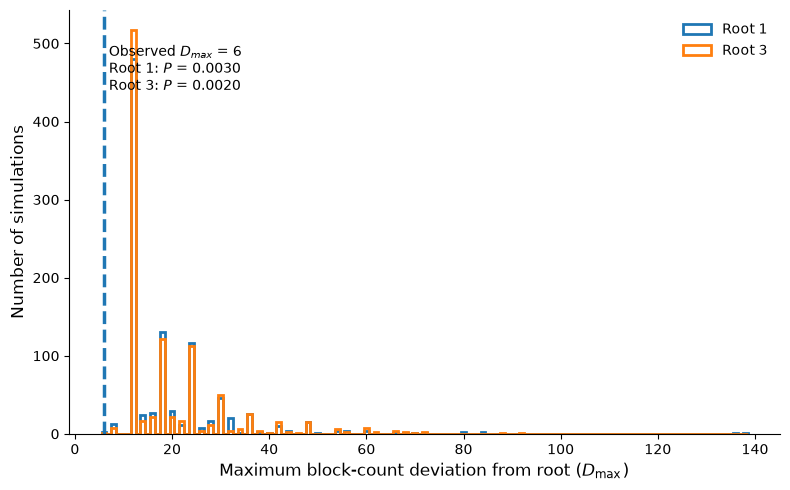

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))

for root_architecture in possible_roots_internal:

    tmp = confirmatory_null_df[
        confirmatory_null_df["root_architecture"]
        == root_architecture
    ]

    ax.hist(
        tmp["max_block_deviation"],
        bins=np.arange(
            confirmatory_null_df["max_block_deviation"].min() - 0.5,
            confirmatory_null_df["max_block_deviation"].max() + 1.5,
            1
        ),
        histtype="step",
        linewidth=2,
        label=root_architecture.replace("Architecture:", "Root ")
    )

ax.axvline(
    OBSERVED_MAX_BLOCK_DEVIATION,
    linestyle="--",
    linewidth=2.5
)

ax.text(
    OBSERVED_MAX_BLOCK_DEVIATION + 1,
    ax.get_ylim()[1] * 0.92,
    (
        "Observed $D_{max}$ = 6\n"
        "Root 1: $P$ = 0.0030\n"
        "Root 3: $P$ = 0.0020"
    ),
    fontsize=10,
    va="top"
)

ax.set_xlabel(
    r"Maximum block-count deviation from root ($D_{\max}$)",
    fontsize=12
)

ax.set_ylabel(
    "Number of simulations",
    fontsize=12
)

ax.legend(
    frameon=False,
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "AZFc_Null1_Dmax_distribution_annotated.pdf",
    bbox_inches="tight"
)

plt.show()

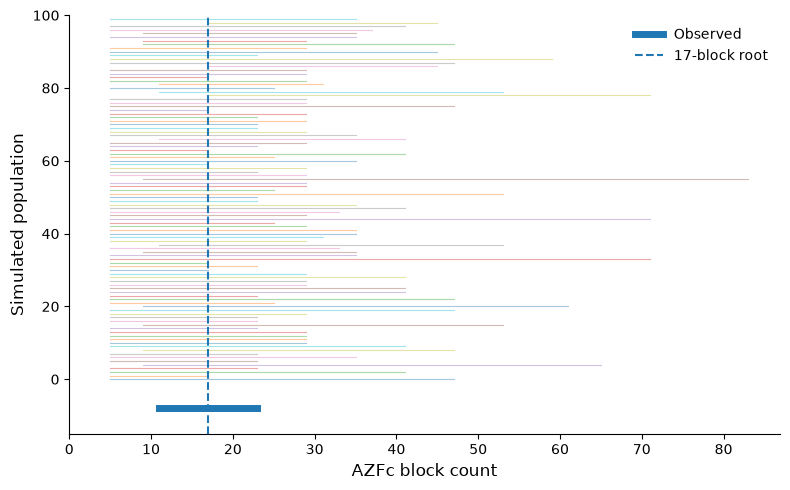

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = confirmatory_null_df[
    confirmatory_null_df["root_architecture"]
    == "Architecture:3"
].copy()

rng = np.random.default_rng(42)

plot_df = plot_df.sample(
    n=100,
    random_state=42
).reset_index(drop=True)

for i, row in plot_df.iterrows():

    ax.plot(
        [
            row["min_terminal_blocks"],
            row["max_terminal_blocks"]
        ],
        [i, i],
        linewidth=0.8,
        alpha=0.4
    )

ax.plot(
    [
        OBSERVED_MIN_BLOCKS,
        OBSERVED_MAX_BLOCKS
    ],
    [-8, -8],
    linewidth=5,
    label="Observed"
)

# Root
ax.axvline(
    ROOT_BLOCK_COUNT,
    linestyle="--",
    linewidth=1.5,
    label="17-block root"
)

ax.set_xlabel(
    "AZFc block count",
    fontsize=12
)

ax.set_ylabel(
    "Simulated population",
    fontsize=12
)

ax.set_ylim(
    -15,
    len(plot_df)
)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Start x-axis at zero
ax.set_xlim(left=0)

plt.tight_layout()

plt.savefig(
    "AZFc_Null1_structural_ranges.pdf",
    bbox_inches="tight"
)

plt.show()

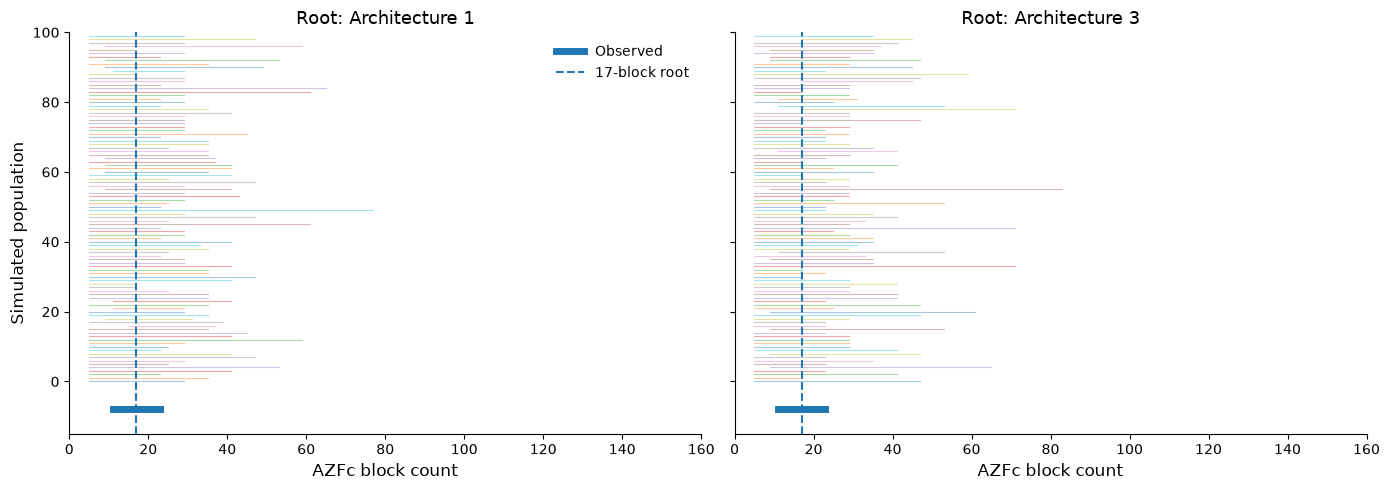

In [61]:
import matplotlib.pyplot as plt
import numpy as np

roots = [
    "Architecture:1",
    "Architecture:3"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
    sharey=True
)

max_x = confirmatory_null_df[
    "max_terminal_blocks"
].max()

for ax, root in zip(axes, roots):

    plot_df = confirmatory_null_df[
        confirmatory_null_df["root_architecture"]
        == root
    ].copy()

    # Randomly display 100 of the 1,000 simulations
    plot_df = plot_df.sample(
        n=100,
        random_state=42
    ).reset_index(drop=True)

    # Simulated population ranges
    for i, row in plot_df.iterrows():

        ax.plot(
            [
                row["min_terminal_blocks"],
                row["max_terminal_blocks"]
            ],
            [i, i],
            linewidth=0.8,
            alpha=0.4
        )


    ax.plot(
        [
            OBSERVED_MIN_BLOCKS,
            OBSERVED_MAX_BLOCKS
        ],
        [-8, -8],
        linewidth=5,
        label="Observed"
    )


    ax.axvline(
        ROOT_BLOCK_COUNT,
        linestyle="--",
        linewidth=1.5,
        label="17-block root"
    )

    ax.set_title(
        f"Root: {root.replace('Architecture:', 'Architecture ')}",
        fontsize=13
    )

    ax.set_xlabel(
        "AZFc block count",
        fontsize=12
    )

    ax.set_xlim(
        0,
        max_x + 5
    )

    ax.set_ylim(
        -15,
        len(plot_df)
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


axes[0].set_ylabel(
    "Simulated population",
    fontsize=12
)

axes[0].legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "AZFc_Null1_structural_ranges_both_roots.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "AZFc_Null1_structural_ranges_both_roots.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

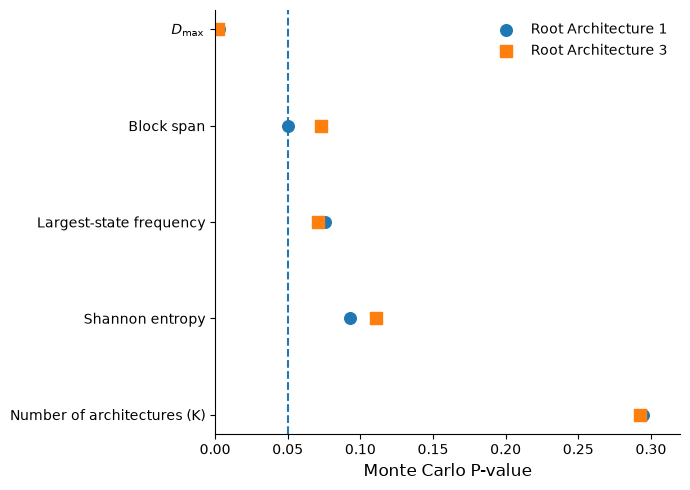

In [62]:
plot_pvalues = pd.DataFrame({
    "Statistic": [
        r"$D_{\max}$",
        "Block span",
        "Largest-state frequency",
        "Shannon entropy",
        "Number of architectures (K)"
    ],

    "Architecture:1": [
        0.002997,
        0.049950,
        0.075924,
        0.092907,
        0.294705
    ],

    "Architecture:3": [
        0.001998,
        0.072927,
        0.070929,
        0.110889,
        0.292707
    ]
})

fig, ax = plt.subplots(figsize=(7, 5))

y = np.arange(
    len(plot_pvalues)
)

ax.scatter(
    plot_pvalues["Architecture:1"],
    y,
    s=70,
    label="Root Architecture 1"
)

ax.scatter(
    plot_pvalues["Architecture:3"],
    y,
    s=70,
    marker="s",
    label="Root Architecture 3"
)

ax.axvline(
    0.05,
    linestyle="--",
    linewidth=1.5
)

ax.set_yticks(y)

ax.set_yticklabels(
    plot_pvalues["Statistic"]
)

ax.invert_yaxis()

ax.set_xlabel(
    "Monte Carlo P-value",
    fontsize=12
)

ax.set_xlim(
    0,
    0.32
)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "AZFc_Null1_statistic_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

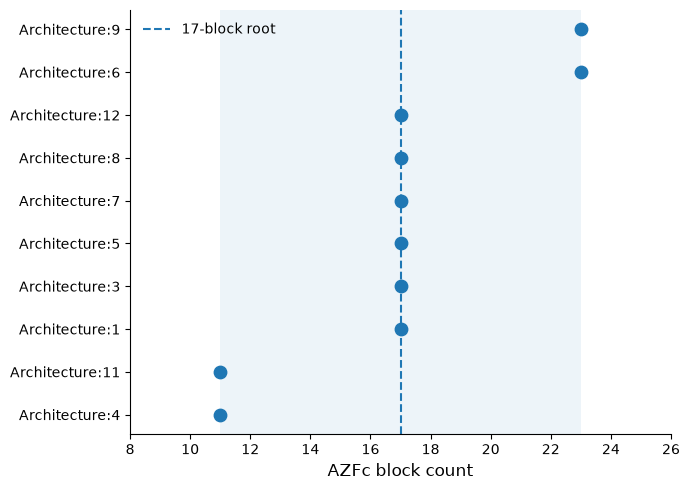

In [63]:
observed_architecture_blocks = pd.DataFrame({
    "Architecture": [
        "Architecture:1",
        "Architecture:3",
        "Architecture:4",
        "Architecture:5",
        "Architecture:6",
        "Architecture:7",
        "Architecture:8",
        "Architecture:9",
        "Architecture:11",
        "Architecture:12"
    ],

    "Blocks": [
        17,
        17,
        11,
        17,
        23,
        17,
        17,
        23,
        11,
        17
    ]
})

observed_architecture_blocks = (
    observed_architecture_blocks
    .sort_values("Blocks")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(7, 5))

y = np.arange(
    len(observed_architecture_blocks)
)

ax.scatter(
    observed_architecture_blocks["Blocks"],
    y,
    s=80
)

ax.axvline(
    ROOT_BLOCK_COUNT,
    linestyle="--",
    linewidth=1.5,
    label="17-block root"
)

ax.axvspan(
    OBSERVED_MIN_BLOCKS,
    OBSERVED_MAX_BLOCKS,
    alpha=0.08
)

ax.set_yticks(y)

ax.set_yticklabels(
    observed_architecture_blocks[
        "Architecture"
    ]
)

ax.set_xlabel(
    "AZFc block count",
    fontsize=12
)

ax.set_xlim(
    8,
    26
)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "AZFc_observed_architecture_block_counts.pdf",
    bbox_inches="tight"
)

plt.show()

In [64]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
============================================================

def get_tree_coordinates(tree):
    """
    Generate rectangular phylogram coordinates.

    x = cumulative branch length
    y = terminal ordering
    """

    x_pos = tree.depths()

    if max(x_pos.values()) == 0:
        x_pos = tree.depths(unit_branch_lengths=True)

    terminals = tree.get_terminals()

    y_pos = {
        tip: len(terminals) - i
        for i, tip in enumerate(terminals)
    }

    def calculate_internal_y(clade):

        if clade in y_pos:
            return y_pos[clade]

        child_y = [
            calculate_internal_y(child)
            for child in clade.clades
        ]

        y_pos[clade] = (
            min(child_y) + max(child_y)
        ) / 2

        return y_pos[clade]

    calculate_internal_y(tree.root)

    return x_pos, y_pos

def plot_azfc_tree(
    ax,
    tree,
    root_architecture,
    architecture_colors,
    show_tip_labels=True,
):

    assigned_states = (
        traceback_results_internal[
            root_architecture
        ]["assigned"]
    )

    x_pos, y_pos = get_tree_coordinates(
        tree
    )

    parent_lookup = {}

    for parent in tree.find_clades(
        order="preorder"
    ):

        for child in parent.clades:
            parent_lookup[child] = parent


    for parent in tree.find_clades(
        order="preorder"
    ):

        if not parent.clades:
            continue

        parent_x = x_pos[parent]
        parent_y = y_pos[parent]

        child_ys = [
            y_pos[child]
            for child in parent.clades
        ]

        ax.plot(
            [parent_x, parent_x],
            [
                min(child_ys),
                max(child_ys)
            ],
            linewidth=0.7,
            color="0.65"
        )

        for child in parent.clades:

            child_x = x_pos[child]
            child_y = y_pos[child]

            parent_state = (
                assigned_states[parent]
            )

            child_state = (
                assigned_states[child]
            )

            architecture_changed = (
                parent_state != child_state
            )

            if architecture_changed:

                branch_color = (
                    architecture_colors[
                        child_state
                    ]
                )

                linewidth = 2.2
                alpha = 1.0

            else:

                branch_color = "0.65"
                linewidth = 0.7
                alpha = 0.8

            ax.plot(
                [
                    parent_x,
                    child_x
                ],
                [
                    child_y,
                    child_y
                ],
                linewidth=linewidth,
                color=branch_color,
                alpha=alpha
            )


            if architecture_changed:

                transition = (
                    parent_state,
                    child_state
                )

                if transition not in nahr_cost_lookup:

                    raise ValueError(
                        "Missing NAHR cost for "
                        f"{parent_state} -> "
                        f"{child_state}"
                    )

                n_events = (
                    nahr_cost_lookup[
                        transition
                    ]
                )

                midpoint_x = (
                    parent_x
                    + child_x
                ) / 2

                label = (
                    f"{n_events}"
                )

                ax.text(
                    midpoint_x,
                    child_y + 0.22,
                    label,
                    ha="center",
                    va="bottom",
                    fontsize=5.5,
                    fontweight="bold"
                )

 
    max_x = max(x_pos.values())

    label_offset = (
        max_x * 0.015
    )

    for tip in tree.get_terminals():

        x = x_pos[tip]
        y = y_pos[tip]

        architecture = (
            architecturalGroupDict[
                tip.name
            ]
        )

        ax.scatter(
            x,
            y,
            s=18,
            color=architecture_colors[
                architecture
            ],
            zorder=5
        )

        if show_tip_labels:

            short_architecture = (
                architecture.replace(
                    "Architecture:",
                    "A"
                )
            )

            ax.text(
                x + label_offset,
                y,
                (
                    f"{tip.name}  |  "
                    f"{short_architecture}"
                ),
                va="center",
                fontsize=5.5,
                color=architecture_colors[
                    architecture
                ]
            )


    root_x = x_pos[tree.root]
    root_y = y_pos[tree.root]

    ax.scatter(
        root_x,
        root_y,
        s=55,
        color=architecture_colors[
            root_architecture
        ],
        zorder=6
    )

    ax.text(
        root_x,
        root_y + 2,
        root_architecture.replace(
            "Architecture:",
            "Root A"
        ),
        fontsize=9,
        fontweight="bold"
    )


    architecture_changes = 0
    total_nahr_events = 0

    for child, parent in parent_lookup.items():

        parent_state = (
            assigned_states[parent]
        )

        child_state = (
            assigned_states[child]
        )

        if parent_state != child_state:

            architecture_changes += 1

            total_nahr_events += (
                nahr_cost_lookup[
                    (
                        parent_state,
                        child_state
                    )
                ]
            )

    ax.set_title(
        (
            f"Root = {root_architecture}\n"
            f"{architecture_changes} architecture changes; "
            f"{total_nahr_events} minimum NAHR events"
        ),
        fontsize=12
    )

    ax.set_xlabel(
        "Y-chromosome phylogenetic branch length",
        fontsize=10
    )

    ax.set_yticks([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    return {
        "architecture_changes":
            architecture_changes,

        "minimum_nahr_events":
            total_nahr_events,
    }

In [65]:
internal_architecture_list = sorted(
    internal_architectures,
    key=lambda x: int(
        x.split(":")[1]
    )
)

cmap = plt.get_cmap(
    "tab10"
)

architecture_colors = {
    architecture:
        cmap(i)
    for i, architecture
    in enumerate(
        internal_architecture_list
    )
}

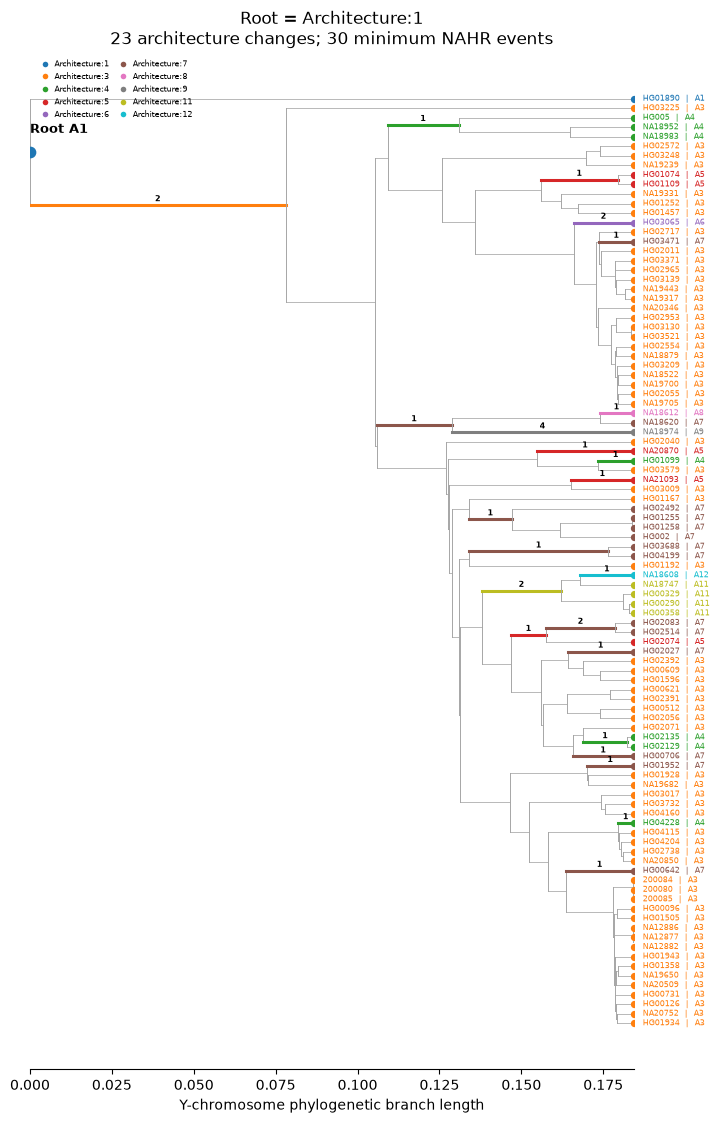

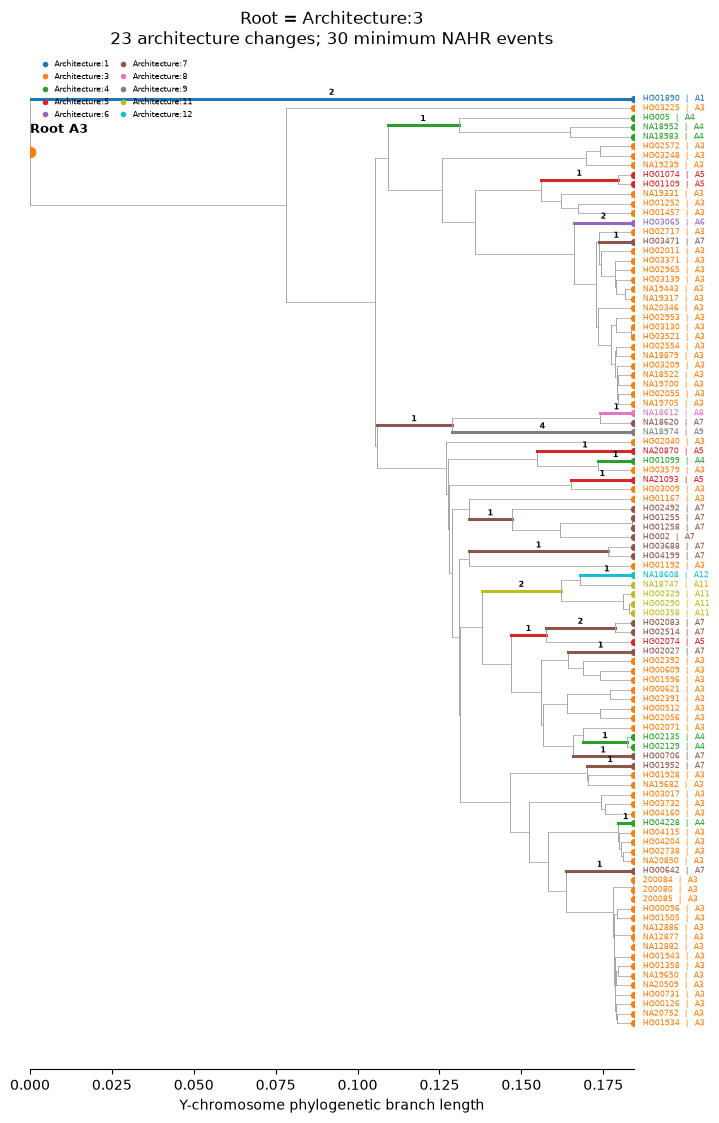

In [67]:
from matplotlib.lines import Line2D
import numpy as np

root_results = {}

for root_architecture in [
    "Architecture:1",
    "Architecture:3"
]:

    fig, ax = plt.subplots(
        figsize=(8.27, 11.69)
    )

    root_results[root_architecture] = plot_azfc_tree(
        ax=ax,
        tree=tree_internal,
        root_architecture=root_architecture,
        architecture_colors=architecture_colors,
    )

    for text in ax.texts:
        label = text.get_text()

        if " | A" in label:
            _, y = text.get_position()

            text.set_position(
                (1.01, y)
            )

            text.set_transform(
                ax.get_yaxis_transform()
            )

            text.set_ha("left")
            text.set_va("center")
            text.set_fontsize(5.5)
            text.set_clip_on(False)

    branch_x_values = []

    for line in ax.lines:
        xdata = np.asarray(
            line.get_xdata(),
            dtype=float
        )

        xdata = xdata[
            np.isfinite(xdata)
        ]

        if len(xdata) > 0:
            branch_x_values.extend(
                xdata.tolist()
            )

    if branch_x_values:
        max_branch_x = max(
            branch_x_values
        )

        ax.set_xlim(
            0,
            max_branch_x
        )

    ax.margins(
        x=0
    )


    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markersize=4,
            markerfacecolor=architecture_colors[architecture],
            markeredgecolor="none",
            label=architecture
        )
        for architecture
        in internal_architecture_list
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        frameon=False,
        fontsize=5.5,
        ncol=2,
        columnspacing=0.8,
        handletextpad=0.3
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.80,
        bottom=0.07,
        top=0.94
    )

    root_number = root_architecture.split(":")[1]

    fig.savefig(
        f"AZFc_parsimony_tree_root_Architecture{root_number}_A4.pdf"
    )

    fig.savefig(
        f"AZFc_parsimony_tree_root_Architecture{root_number}_A4.png",
        dpi=600
    )

    plt.show()

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def build_azfc_dmax_summary_table(
    confirmatory_null_df,
    confirmatory_test_summary,
    event_sensitivity_df,
    event_sensitivity_test_summary,
    output_prefix="AZFc_Dmax_summary_table"
):
    """
    Build a summary table for the AZFc Dmax
    architectural-constraint analysis at 30, 31, and 32
    state-changing NAHR events.

    Outputs:
        <output_prefix>.csv
        <output_prefix>.svg

    Returns:
        manuscript_table : pandas.DataFrame
    """

    dist_30 = (
        confirmatory_null_df
        .groupby("root_architecture")["max_block_deviation"]
        .agg(
            null_median="median",
            null_q025=lambda x: x.quantile(0.025),
            null_q975=lambda x: x.quantile(0.975),
        )
        .reset_index()
    )

    test_30 = confirmatory_test_summary[
        [
            "root_architecture",
            "n_simulations",
            "observed_Dmax",
            "simulations_Dmax_le_observed",
            "p_Dmax",
        ]
    ].copy()

    test_30["target_events"] = 30

    test_30 = test_30.rename(
        columns={
            "p_Dmax": "monte_carlo_p"
        }
    )

    summary_30 = test_30.merge(
        dist_30,
        on="root_architecture",
        how="left"
    )


    dist_sensitivity = (
        event_sensitivity_df
        .groupby(
            [
                "target_events",
                "root_architecture",
            ]
        )["max_block_deviation"]
        .agg(
            null_median="median",
            null_q025=lambda x: x.quantile(0.025),
            null_q975=lambda x: x.quantile(0.975),
        )
        .reset_index()
    )

    test_sensitivity = event_sensitivity_test_summary[
        [
            "target_events",
            "root_architecture",
            "n_simulations",
            "observed_Dmax",
            "simulations_Dmax_le_observed",
            "monte_carlo_p_Dmax",
        ]
    ].copy()

    test_sensitivity = test_sensitivity.rename(
        columns={
            "monte_carlo_p_Dmax": "monte_carlo_p"
        }
    )

    summary_sensitivity = test_sensitivity.merge(
        dist_sensitivity,
        on=[
            "target_events",
            "root_architecture",
        ],
        how="left"
    )


    combined = pd.concat(
        [
            summary_30,
            summary_sensitivity,
        ],
        ignore_index=True
    )

    combined = combined.sort_values(
        [
            "target_events",
            "root_architecture",
        ]
    ).reset_index(
        drop=True
    )

    root_labels = {
        "Architecture:1":
            "Architecture:1 (HG01890-like)",

        "Architecture:3":
            "Architecture:3 (GRCh38-like)",
    }

    combined["root_label"] = (
        combined["root_architecture"]
        .map(root_labels)
        .fillna(combined["root_architecture"])
    )


    manuscript_table = pd.DataFrame(
        {
            "Conditioned NAHR events":
                combined["target_events"].astype(int),

            "Root":
                combined["root_label"],

            "Observed Dmax":
                combined["observed_Dmax"].astype(int),

            "Null median Dmax":
                combined["null_median"].apply(
                    lambda x:
                        int(x)
                        if float(x).is_integer()
                        else round(x, 2)
                ),

            "Null 95% interval":
                combined.apply(
                    lambda row:
                        (
                            f"{row['null_q025']:.0f}"
                            f"\u2013"
                            f"{row['null_q975']:.0f}"
                        ),
                    axis=1
                ),

            "Simulations <= observed":
                combined.apply(
                    lambda row:
                        (
                            f"{int(row['simulations_Dmax_le_observed'])}"
                            f"/"
                            f"{int(row['n_simulations'])}"
                        ),
                    axis=1
                ),

            "Monte Carlo P":
                combined["monte_carlo_p"].apply(
                    lambda x: f"{x:.6f}"
                ),
        }
    )


    csv_path = Path(
        f"{output_prefix}.csv"
    )

    manuscript_table.to_csv(
        csv_path,
        index=False
    )

    svg_path = Path(
        f"{output_prefix}.svg"
    )

    fig, ax = plt.subplots(
        figsize=(12, 3.0)
    )

    ax.axis("off")

    table = ax.table(
        cellText=manuscript_table.values,
        colLabels=manuscript_table.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)

    table.scale(
        1.0,
        1.6
    )

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(
                weight="bold"
            )

    table.auto_set_column_width(
        col=list(
            range(
                len(manuscript_table.columns)
            )
        )
    )

    fig.savefig(
        svg_path,
        format="svg",
        bbox_inches="tight"
    )

    plt.close(fig)

    print(
        f"Saved CSV: {csv_path.resolve()}"
    )

    print(
        f"Saved SVG: {svg_path.resolve()}"
    )

    return manuscript_table

In [73]:
azfc_dmax_table = build_azfc_dmax_summary_table(
    confirmatory_null_df=confirmatory_null_df,
    confirmatory_test_summary=confirmatory_test_summary,
    event_sensitivity_df=event_sensitivity_df,
    event_sensitivity_test_summary=event_sensitivity_test_summary,
)

display(azfc_dmax_table)

Saved CSV: /Users/markloftus/Desktop/UCONN/anaconda_projects/chrY/Pan-Y_Paper/Constraint/AZFc_Dmax_summary_table.csv
Saved SVG: /Users/markloftus/Desktop/UCONN/anaconda_projects/chrY/Pan-Y_Paper/Constraint/AZFc_Dmax_summary_table.svg


,Conditioned NAHR events,Root,Observed Dmax,Null median Dmax,Null 95% interval,Simulations <= observed,Monte Carlo P
0,30,Architecture:1 (HG01890-like),6,14,12–48,2/1000,0.002997
1,30,Architecture:3 (GRCh38-like),6,12,12–54,1/1000,0.001998
2,31,Architecture:1 (HG01890-like),6,16,12–54,0/1000,0.000999
3,31,Architecture:3 (GRCh38-like),6,16,12–50,1/1000,0.001998
4,32,Architecture:1 (HG01890-like),6,18,12–54,0/1000,0.000999
5,32,Architecture:3 (GRCh38-like),6,16,12–60,0/1000,0.000999
